In [102]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.ensemble import (
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor
)
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.inspection import permutation_importance
from sklearn.model_selection import KFold, cross_validate, GridSearchCV

warnings.filterwarnings("ignore")

In [81]:
data = pd.read_csv("Cleaned_PANCANCER_IC50.csv")

In [3]:
data

,Drug Name,Drug ID,Cell Line Name,Cosmic ID,TCGA Classification,Tissue,Tissue Sub-type,IC50,AUC,Max Conc,RMSE,Z score,Dataset Version
0,123138,1824,PFSK-1,683667,MB,nervous_system,medulloblastoma,2.100251,0.972302,1.0,0.025546,-0.955691,GDSC2
1,123138,1824,A673,684052,UNCLASSIFIED,soft_tissue,rhabdomyosarcoma,2.705026,0.984602,1.0,0.087033,-0.224533,GDSC2
2,123138,1824,COLO-829,687448,SKCM,skin,melanoma,4.720098,0.972596,1.0,0.061260,2.211641,GDSC2
3,123138,1824,5637,687452,BLCA,urogenital_system,bladder,2.883005,0.974763,1.0,0.072336,-0.009361,GDSC2
4,123138,1824,C-33-A,687505,CESC,urogenital_system,cervix,2.124045,0.966583,1.0,0.148647,-0.926925,GDSC2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9219,glutathione,2439,HEC-1,907051,UCEC,urogenital_system,endometrium,10.202357,0.985499,640.0,0.022300,1.162487,GDSC2
9220,glutathione,2439,HLE,907057,LIHC,digestive_system,liver,9.585744,0.983767,640.0,0.034264,0.471265,GDSC2
9221,glutathione,2439,JVM-2,907269,CLL,blood,lymphoid_neoplasm_other,9.527786,0.981401,640.0,0.041364,0.406294,GDSC2
9222,glutathione,2439,NCCIT,908441,NaN,urogenital_system,testis,8.934915,0.978454,640.0,0.030767,-0.258314,GDSC2


In [4]:
data.columns = data.columns.str.strip().str.lower()

In [5]:
gbm_data = data[
    (data['tissue'] == 'nervous_system') &
    (data['tissue sub-type'] == 'glioma') &
    (data['tcga classification'] == 'GBM')
]

In [6]:
gbm_data

,drug name,drug id,cell line name,cosmic id,tcga classification,tissue,tissue sub-type,ic50,auc,max conc,rmse,z score,dataset version
5,123138,1824,42-MG-BA,687561,GBM,nervous_system,glioma,1.965690,0.964035,1.0,0.063807,-1.118372,GDSC2
36,123829,1820,42-MG-BA,687561,GBM,nervous_system,glioma,1.598358,0.904771,3.0,0.070817,-0.610460,GDSC2
67,150412,1836,42-MG-BA,687561,GBM,nervous_system,glioma,3.193771,0.967204,3.0,0.085820,0.026407,GDSC2
98,5-Fluorouracil,1073,42-MG-BA,687561,GBM,nervous_system,glioma,3.463196,0.880093,32.0,0.138802,-0.538120,GDSC2
130,5-azacytidine,2156,42-MG-BA,687561,GBM,nervous_system,glioma,4.006807,0.931015,20.0,0.012071,0.732362,GDSC2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9068,ZM447439,1050,42-MG-BA,687561,GBM,nervous_system,glioma,1.734766,0.827217,10.0,0.085399,-0.494035,GDSC2
9102,Zoledronate,1802,42-MG-BA,687561,GBM,nervous_system,glioma,3.545706,0.981131,2.0,0.033839,-0.345030,GDSC2
9133,alpha-lipoic acid,2498,42-MG-BA,687561,GBM,nervous_system,glioma,7.955085,0.984992,121.0,0.032255,0.316092,GDSC2
9164,ascorbate (vitamin C),2438,42-MG-BA,687561,GBM,nervous_system,glioma,9.616954,0.965299,2000.0,0.036698,-0.494480,GDSC2


In [7]:
top_10_stat = gbm_data.nlargest(
    10,
    'auc'
)[['cell line name', 'drug name', 'auc']]

In [85]:
data.columns

Index(['Drug Name', 'Drug ID', 'Cell Line Name', 'Cosmic ID',
       'TCGA Classification', 'Tissue', 'Tissue Sub-type', 'IC50', 'AUC',
       'Max Conc', 'RMSE', 'Z score', 'Dataset Version'],
      dtype='object')

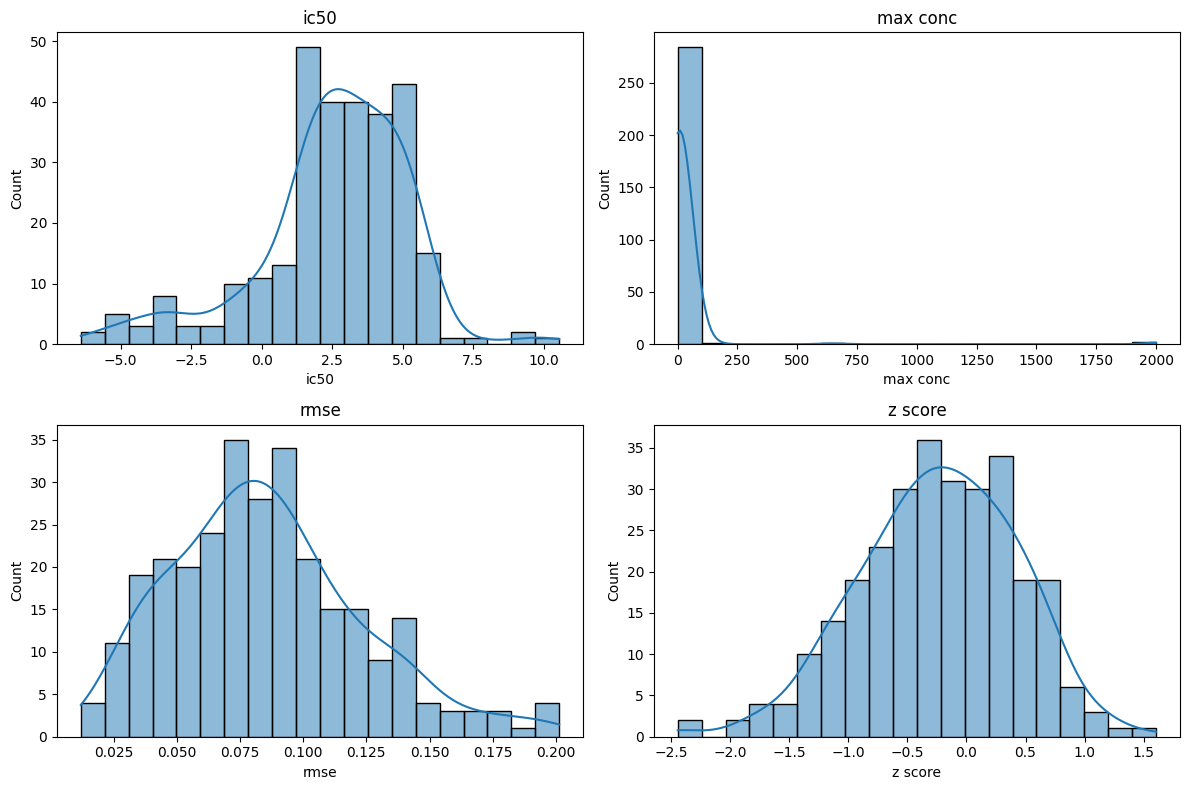

In [83]:
# =============================================================================
# Feature Distribution (Seaborn)
# =============================================================================

features = ['ic50', 'max conc', 'rmse', 'z score']

fig, axes = plt.subplots(2, 2, figsize=(12,8))

for ax, feature in zip(axes.flatten(), features):

    sns.histplot(
        gbm_data[feature],
        kde=True,
        bins=20,
        ax=ax
    )

    ax.set_title(feature)

plt.tight_layout()

plt.show()

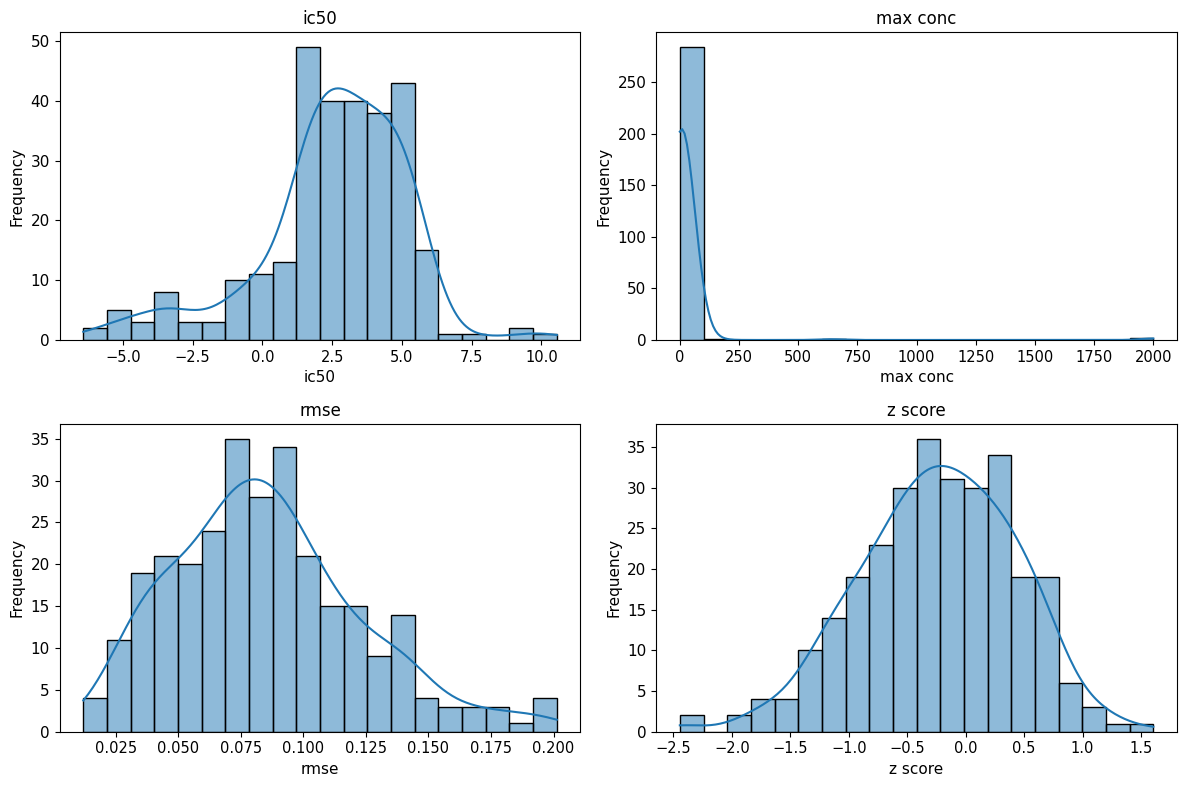

In [165]:
# =============================================================================
# Feature Distribution (Seaborn)
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

features = ['ic50', 'max conc', 'rmse', 'z score']

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 8)
)

for ax, feature in zip(axes.flatten(), features):

    sns.histplot(
        gbm_data[feature],
        kde=True,
        bins=20,
        ax=ax
    )

    ax.set_title(feature, fontsize=12)
    ax.set_xlabel(feature, fontsize=11)
    ax.set_ylabel("Frequency", fontsize=11)

plt.tight_layout()

# =============================================================================
# Save as PNG
# =============================================================================

plt.savefig(
    "Feature_Distribution.png",
    dpi=600,
    bbox_inches="tight"
)

# =============================================================================
# Save as PDF
# =============================================================================

plt.savefig(
    "Feature_Distribution.pdf",
    format="pdf",
    bbox_inches="tight"
)

# Display figure
plt.show()

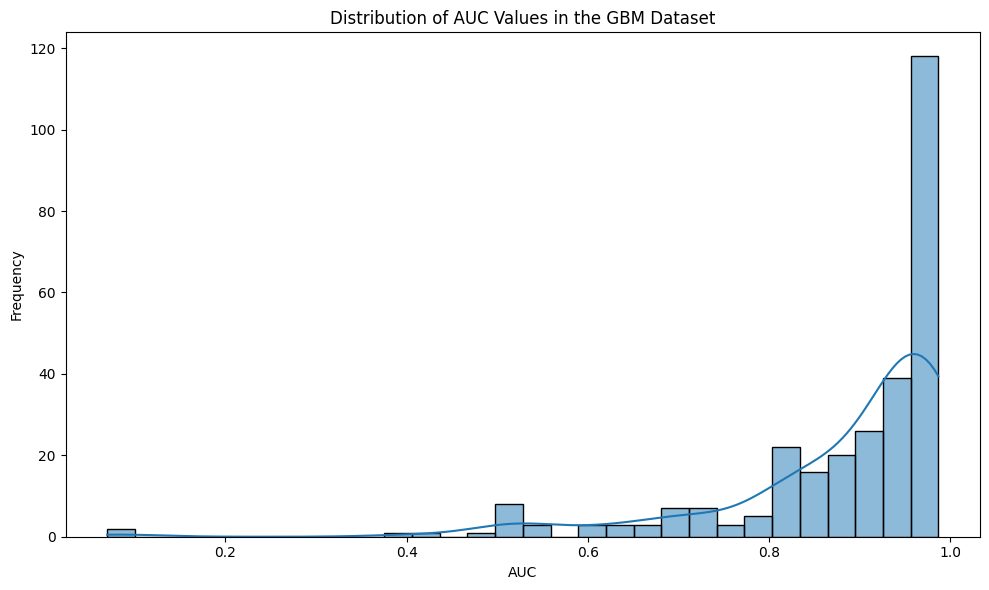

In [124]:
plt.figure(figsize=(10, 6))

sns.histplot(gbm_data['auc'], bins=30, kde=True)

plt.title('Distribution of AUC Values in the GBM Dataset')
plt.xlabel('AUC')
plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig('AUC_Distribution.png', dpi=300, bbox_inches='tight')
plt.show()

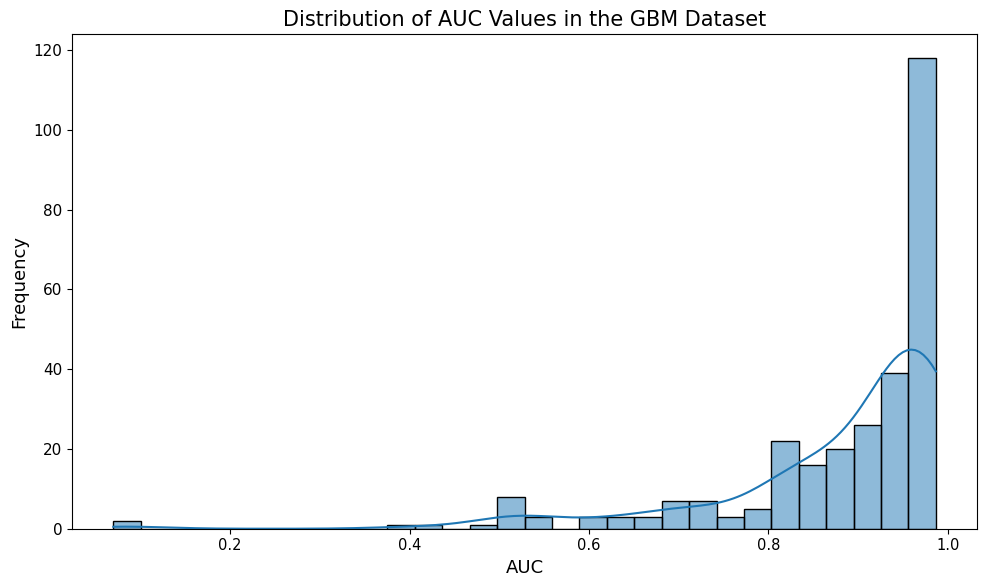

In [153]:
plt.figure(figsize=(10, 6))

sns.histplot(gbm_data['auc'], bins=30, kde=True)

plt.title('Distribution of AUC Values in the GBM Dataset')
plt.xlabel('AUC')
plt.ylabel('Frequency')

plt.tight_layout()

# Save as PDF
plt.savefig(
    'AUC_Distribution.pdf',
    format='pdf',
    bbox_inches='tight'
)

plt.show()

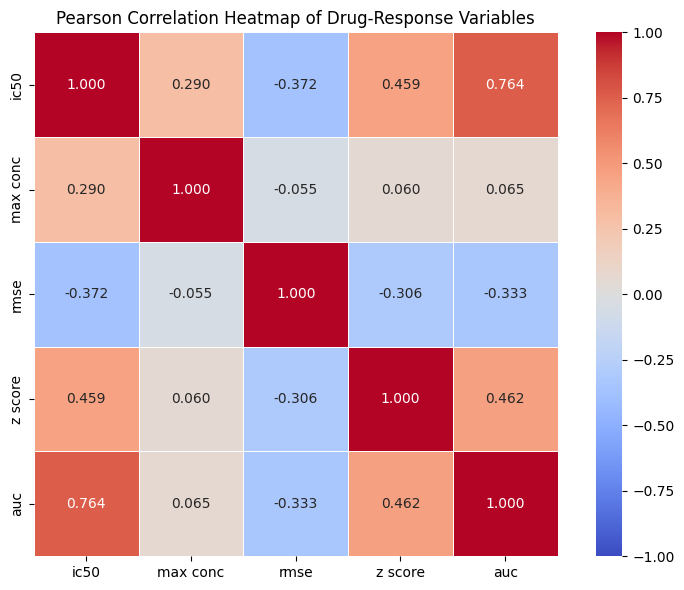

In [125]:
# =============================================================================
# Figure 3: Pearson Correlation Heatmap
# =============================================================================


# Select response-related variables and AUC
corr_features = [
    'ic50',
    'max conc',
    'rmse',
    'z score',
    'auc'
]

# Calculate Pearson correlation matrix
corr_matrix = gbm_data[corr_features].corr(method='pearson')

# Plot heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True
)

plt.title('Pearson Correlation Heatmap of Drug-Response Variables')
plt.xlabel('')
plt.ylabel('')

plt.tight_layout()

# Save publication-quality figure
plt.savefig(
    'Figure_3_Pearson_Correlation_Heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

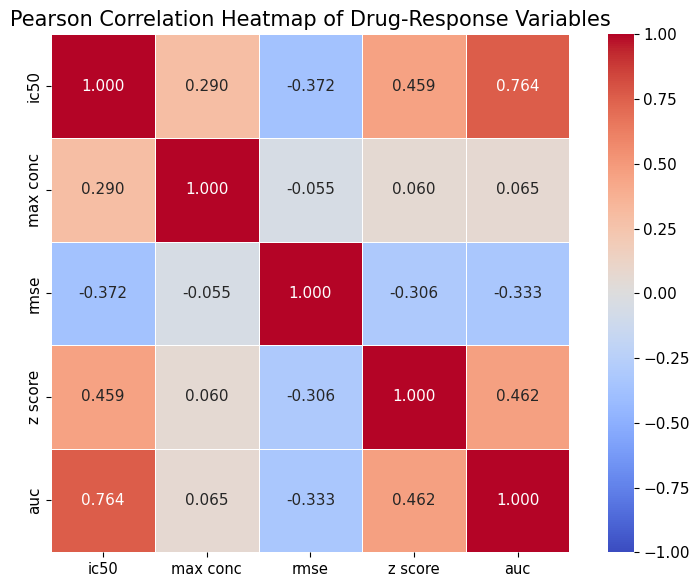

In [154]:
# =============================================================================
# Figure 3: Pearson Correlation Heatmap
# =============================================================================

# Select response-related variables and AUC
corr_features = [
    'ic50',
    'max conc',
    'rmse',
    'z score',
    'auc'
]

# Calculate Pearson correlation matrix
corr_matrix = gbm_data[corr_features].corr(method='pearson')

# Plot heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True
)

plt.title('Pearson Correlation Heatmap of Drug-Response Variables')
plt.xlabel('')
plt.ylabel('')

plt.tight_layout()

# Save as publication-quality PDF
plt.savefig(
    'Figure_3_Pearson_Correlation_Heatmap.pdf',
    format='pdf',
    bbox_inches='tight'
)

plt.show()

In [8]:
features = [
    'ic50',
    'max conc',
    'rmse',
    'z score'
]

X = gbm_data[features]

y = gbm_data['auc']

original_info = gbm_data[
    ['cell line name', 'drug name']
]

In [9]:
X_train, X_test, y_train, y_test, info_train, info_test = train_test_split(
    X,
    y,
    original_info,
    test_size=0.30,
    random_state=42
)

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [11]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train_scaled,
    y_train
)

y_pred_rf = rf_model.predict(
    X_test_scaled
)

mse_rf = mean_squared_error(
    y_test,
    y_pred_rf
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

In [12]:
adaboost_model = AdaBoostRegressor(
    n_estimators=100,
    random_state=42
)

adaboost_model.fit(
    X_train_scaled,
    y_train
)

y_pred_adaboost = adaboost_model.predict(
    X_test_scaled
)

mse_adaboost = mean_squared_error(
    y_test,
    y_pred_adaboost
)

r2_adaboost = r2_score(
    y_test,
    y_pred_adaboost
)

In [13]:
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

gb_model.fit(
    X_train_scaled,
    y_train
)

y_pred_gb = gb_model.predict(
    X_test_scaled
)

mse_gb = mean_squared_error(
    y_test,
    y_pred_gb
)

r2_gb = r2_score(
    y_test,
    y_pred_gb
)

In [14]:
print(f"RandomForest - R2: {r2_rf:.3f}, MSE: {mse_rf:.3f}")

print(f"AdaBoost - R2: {r2_adaboost:.3f}, MSE: {mse_adaboost:.3f}")

print(f"GradientBoosting - R2: {r2_gb:.3f}, MSE: {mse_gb:.3f}")

RandomForest - R2: 0.827, MSE: 0.004
AdaBoost - R2: 0.749, MSE: 0.006
GradientBoosting - R2: 0.907, MSE: 0.002


In [15]:
info_test['Predicted_AUC_RF'] = y_pred_rf

info_test['Predicted_AUC_Adaboost'] = y_pred_adaboost

info_test['Predicted_AUC_GB'] = y_pred_gb

In [16]:
comparison_data = pd.concat([
    top_10_stat.assign(
        Source='Statistical Method'
    ),

    info_test[
        ['cell line name',
         'drug name',
         'Predicted_AUC_RF']
    ].rename(
        columns={
            'Predicted_AUC_RF':'auc'
        }
    ).assign(
        Source='ML Prediction - RF'
    ),

    info_test[
        ['cell line name',
         'drug name',
         'Predicted_AUC_Adaboost']
    ].rename(
        columns={
            'Predicted_AUC_Adaboost':'auc'
        }
    ).assign(
        Source='ML Prediction - AdaBoost'
    ),

    info_test[
        ['cell line name',
         'drug name',
         'Predicted_AUC_GB']
    ].rename(
        columns={
            'Predicted_AUC_GB':'auc'
        }
    ).assign(
        Source='ML Prediction - Gradient Boosting'
    )
])

In [17]:
comparison_data 

,cell line name,drug name,auc,Source
3755,42-MG-BA,GSK2830371A,0.986843,Statistical Method
5885,42-MG-BA,Nutlin-3a (-),0.986038,Statistical Method
2096,42-MG-BA,CCT007093,0.985208,Statistical Method
8609,42-MG-BA,Veliparib,0.985208,Statistical Method
3786,42-MG-BA,GSK3337463A,0.985184,Statistical Method
...,...,...,...,...
6698,42-MG-BA,Pictilisib,0.723562,ML Prediction - Gradient Boosting
3474,42-MG-BA,GSK1904529A,0.972248,ML Prediction - Gradient Boosting
6533,42-MG-BA,PRT062607,0.860302,ML Prediction - Gradient Boosting
2866,42-MG-BA,EHT-1864,0.970798,ML Prediction - Gradient Boosting


In [18]:
adaboost_model

,estimator,None
,n_estimators,100
,learning_rate,1.0
,loss,'linear'
,random_state,42


In [21]:
# 5-fold Cross Validation
KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

KFold(n_splits=5, random_state=42, shuffle=True)

### 1. Improve the validation strategy

In [22]:
# Define evaluation metrics
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [23]:
scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

In [24]:
scoring

{'rmse': 'neg_root_mean_squared_error',
 'mae': 'neg_mean_absolute_error',
 'r2': 'r2'}

# Random Forest

In [27]:
# =============================================================================
# RANDOM FOREST - 5 FOLD CROSS VALIDATION
# =============================================================================

rf_results = cross_validate(
    rf_model,
    X_train_scaled,
    y_train,
    cv=kf,
    scoring=scoring,
    return_train_score=False
)

# Convert negative scores back to positive values
rf_rmse = -rf_results['test_rmse']
rf_mae = -rf_results['test_mae']
rf_r2 = rf_results['test_r2']

print("Random Forest Results")
print("---------------------")
print(f"RMSE : {rf_rmse.mean():.4f} ± {rf_rmse.std():.4f}")
print(f"MAE  : {rf_mae.mean():.4f} ± {rf_mae.std():.4f}")
print(f"R²   : {rf_r2.mean():.4f} ± {rf_r2.std():.4f}")

Random Forest Results
---------------------
RMSE : 0.0553 ± 0.0166
MAE  : 0.0262 ± 0.0064
R²   : 0.8078 ± 0.0634


# AdaBoost

In [28]:
# =============================================================================
# ADABOOST - 5 FOLD CROSS VALIDATION
# =============================================================================

adaboost_results = cross_validate(
    adaboost_model,
    X_train_scaled,
    y_train,
    cv=kf,
    scoring=scoring,
    return_train_score=False
)

adaboost_rmse = -adaboost_results['test_rmse']
adaboost_mae = -adaboost_results['test_mae']
adaboost_r2 = adaboost_results['test_r2']

print("\nAdaBoost Results")
print("---------------------")
print(f"RMSE : {adaboost_rmse.mean():.4f} ± {adaboost_rmse.std():.4f}")
print(f"MAE  : {adaboost_mae.mean():.4f} ± {adaboost_mae.std():.4f}")
print(f"R²   : {adaboost_r2.mean():.4f} ± {adaboost_r2.std():.4f}")


AdaBoost Results
---------------------
RMSE : 0.0739 ± 0.0255
MAE  : 0.0474 ± 0.0081
R²   : 0.6159 ± 0.2780


# Gradient Boosting

In [29]:
# =============================================================================
# GRADIENT BOOSTING - 5 FOLD CROSS VALIDATION
# =============================================================================

gb_results = cross_validate(
    gb_model,
    X_train_scaled,
    y_train,
    cv=kf,
    scoring=scoring,
    return_train_score=False
)

gb_rmse = -gb_results['test_rmse']
gb_mae = -gb_results['test_mae']
gb_r2 = gb_results['test_r2']

print("\nGradient Boosting Results")
print("---------------------")
print(f"RMSE : {gb_rmse.mean():.4f} ± {gb_rmse.std():.4f}")
print(f"MAE  : {gb_mae.mean():.4f} ± {gb_mae.std():.4f}")
print(f"R²   : {gb_r2.mean():.4f} ± {gb_r2.std():.4f}")


Gradient Boosting Results
---------------------
RMSE : 0.0394 ± 0.0112
MAE  : 0.0205 ± 0.0047
R²   : 0.9036 ± 0.0288


# Summary Table

In [31]:
# =============================================================================
# SUMMARY TABLE OF CROSS-VALIDATION RESULTS
# =============================================================================

cv_results = pd.DataFrame({
    'Model': [
        'Random Forest',
        'AdaBoost',
        'Gradient Boosting'
    ],
    'RMSE (Mean ± SD)': [
        f"{rf_rmse.mean():.4f} ± {rf_rmse.std():.4f}",
        f"{adaboost_rmse.mean():.4f} ± {adaboost_rmse.std():.4f}",
        f"{gb_rmse.mean():.4f} ± {gb_rmse.std():.4f}"
    ],
    'MAE (Mean ± SD)': [
        f"{rf_mae.mean():.4f} ± {rf_mae.std():.4f}",
        f"{adaboost_mae.mean():.4f} ± {adaboost_mae.std():.4f}",
        f"{gb_mae.mean():.4f} ± {gb_mae.std():.4f}"
    ],
    'R² (Mean ± SD)': [
        f"{rf_r2.mean():.4f} ± {rf_r2.std():.4f}",
        f"{adaboost_r2.mean():.4f} ± {adaboost_r2.std():.4f}",
        f"{gb_r2.mean():.4f} ± {gb_r2.std():.4f}"
    ]
})

print("\nCross-Validation Performance Summary")
print("------------------------------------")
print(cv_results)


Cross-Validation Performance Summary
------------------------------------
               Model RMSE (Mean ± SD)  MAE (Mean ± SD)   R² (Mean ± SD)
0      Random Forest  0.0553 ± 0.0166  0.0262 ± 0.0064  0.8078 ± 0.0634
1           AdaBoost  0.0739 ± 0.0255  0.0474 ± 0.0081  0.6159 ± 0.2780
2  Gradient Boosting  0.0394 ± 0.0112  0.0205 ± 0.0047  0.9036 ± 0.0288


# Random Forest Hyperparameter Tuning

In [36]:
# =============================================================================
# RANDOM FOREST HYPERPARAMETER TUNING
# =============================================================================

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=42))
])

# Define parameter grid
rf_param_grid = {

    'model__n_estimators': [100, 200, 300],

    'model__max_depth': [None, 10, 20, 30],

    'model__min_samples_split': [2, 5, 10],

    'model__min_samples_leaf': [1, 2, 4]

}

# Perform Grid Search
rf_grid = GridSearchCV(

    estimator=rf_pipeline,

    param_grid=rf_param_grid,

    cv=kf,

    scoring='r2',

    n_jobs=-1,

    verbose=1

)

rf_grid.fit(X, y)

print("\nBest Random Forest Parameters")
print("--------------------------------")
print(rf_grid.best_params_)

print("\nBest Cross Validation R²")
print("--------------------------------")
print(rf_grid.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best Random Forest Parameters
--------------------------------
{'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best Cross Validation R²
--------------------------------
0.8391958880659447


In [47]:
# Best Random Forest Model
best_model = rf_grid.best_estimator_

# Train the model
best_model.fit(X_train, y_train)

# Predict on the test set
y_pred = best_model.predict(X_test)

# Evaluation metrics
print("R²:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R²: 0.806262229510007
MSE: 0.0048046640371749655
MAE: 0.027164384925035735


# AdaBoost Hyperparameter Tuning

In [37]:
# =============================================================================
# ADABOOST HYPERPARAMETER TUNING
# =============================================================================

ada_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', AdaBoostRegressor(random_state=42))
])

ada_param_grid = {

    'model__n_estimators': [50, 100, 200, 300],

    'model__learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0]

}

ada_grid = GridSearchCV(

    estimator=ada_pipeline,

    param_grid=ada_param_grid,

    cv=kf,

    scoring='r2',

    n_jobs=-1,

    verbose=1

)

ada_grid.fit(X, y)

print("\nBest AdaBoost Parameters")
print("--------------------------------")
print(ada_grid.best_params_)

print("\nBest Cross Validation R²")
print("--------------------------------")
print(ada_grid.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best AdaBoost Parameters
--------------------------------
{'model__learning_rate': 0.5, 'model__n_estimators': 50}

Best Cross Validation R²
--------------------------------
0.7975041908322688


In [46]:
best_model = ada_grid.best_estimator_
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R²: 0.7959623415742817
MSE: 0.005060099521058933
MAE: 0.036791729146899196


# Gradient Boosting Hyperparameter Tuning

In [ ]:
# =============================================================================
# GRADIENT BOOSTING HYPERPARAMETER TUNING
# =============================================================================

gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GradientBoostingRegressor(random_state=42))
])

gb_param_grid = {

    'model__n_estimators': [100, 200, 300],

    'model__learning_rate': [0.01, 0.05, 0.1],

    'model__max_depth': [3, 5, 7]

}

gb_grid = GridSearchCV(

    estimator=gb_pipeline,

    param_grid=gb_param_grid,

    cv=kf,

    scoring='r2',

    n_jobs=-1,

    verbose=1

)

gb_grid.fit(X, y)

print("\nBest Gradient Boosting Parameters")
print("--------------------------------")
print(gb_grid.best_params_)

print("\nBest Cross Validation R²")
print("--------------------------------")
print(gb_grid.best_score_)

In [48]:
# Best Gradient Boosting Model
best_model = gb_grid.best_estimator_

# Train the model
best_model.fit(X_train, y_train)

# Predict on the test set
y_pred = best_model.predict(X_test)

# Evaluation metrics
print("R²:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R²: 0.920576506943404
MSE: 0.0019696892342195775
MAE: 0.020503783029792506


# Baseline Models LinearRegression, Ridge, Lasso

In [50]:
# =============================================================================
# Define Machine Learning Models LinearRegression, Ridge, Lasso
# =============================================================================

models = {

    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),

    'Ridge Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),

    'Lasso Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.1))
    ]),

    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestRegressor(
            n_estimators=100,
            random_state=42
        ))
    ]),

    'AdaBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('model', AdaBoostRegressor(
            n_estimators=100,
            random_state=42
        ))
    ]),

    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('model', GradientBoostingRegressor(
            n_estimators=100,
            random_state=42
        ))
    ])

}

## Perform 5-Fold Cross Validation LinearRegression, Ridge, Lasso

In [51]:
# =============================================================================
# Evaluate All Models using 5-Fold Cross Validation
# =============================================================================

results = []

for model_name, model in models.items():

    scores = cross_validate(

        estimator=model,

        X=X,

        y=y,

        cv=kf,

        scoring=scoring,

        return_train_score=False

    )

    rmse = -scores['test_rmse']

    mae = -scores['test_mae']

    r2 = scores['test_r2']

    results.append({

        'Model': model_name,

        'RMSE Mean': rmse.mean(),

        'RMSE SD': rmse.std(),

        'MAE Mean': mae.mean(),

        'MAE SD': mae.std(),

        'R² Mean': r2.mean(),

        'R² SD': r2.std()

    })

In [104]:
# =============================================================================
# Tuned Ridge Regression
# =============================================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

# =============================================================================
# Ridge Pipeline
# =============================================================================

ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])


# =============================================================================
# Hyperparameter Grid
# =============================================================================

ridge_param_grid = {
    'ridge__alpha': [
        0.001,
        0.01,
        0.1,
        1,
        10,
        100,
        1000
    ]
}


# =============================================================================
# 5-Fold Cross-Validation for Hyperparameter Tuning
# =============================================================================

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)


# =============================================================================
# Fit Ridge on Training Data
# =============================================================================

ridge_grid.fit(
    X_train,
    y_train
)


# =============================================================================
# Best Parameters
# =============================================================================

print("Best Ridge Parameters:")
print(ridge_grid.best_params_)

print("\nBest 5-Fold CV R²:")
print(ridge_grid.best_score_)


# =============================================================================
# Evaluate on Unseen Test Set
# =============================================================================

best_ridge = ridge_grid.best_estimator_

y_pred_ridge = best_ridge.predict(
    X_test
)


# =============================================================================
# Test Set Metrics
# =============================================================================

ridge_r2 = r2_score(
    y_test,
    y_pred_ridge
)

ridge_mse = mean_squared_error(
    y_test,
    y_pred_ridge
)

ridge_rmse = mean_squared_error(
    y_test,
    y_pred_ridge
) ** 0.5

ridge_mae = mean_absolute_error(
    y_test,
    y_pred_ridge
)


# =============================================================================
# Display Results
# =============================================================================

print("\nTuned Ridge Regression - Unseen Test Set")
print("----------------------------------------")
print("R²   :", ridge_r2)
print("MSE  :", ridge_mse)
print("RMSE :", ridge_rmse)
print("MAE  :", ridge_mae)

Best Ridge Parameters:
{'ridge__alpha': 100}

Best 5-Fold CV R²:
0.4654899767645815

Tuned Ridge Regression - Unseen Test Set
----------------------------------------
R²   : 0.5227179384294953
MSE  : 0.011836514640468523
RMSE : 0.10879574734551219
MAE  : 0.06495069812806402


## Create Comparison Table

In [52]:
# =============================================================================
# Create Model Comparison Table
# =============================================================================

results_df = pd.DataFrame(results)

results_df['RMSE'] = results_df.apply(
    lambda row: f"{row['RMSE Mean']:.4f} ± {row['RMSE SD']:.4f}",
    axis=1
)

results_df['MAE'] = results_df.apply(
    lambda row: f"{row['MAE Mean']:.4f} ± {row['MAE SD']:.4f}",
    axis=1
)

results_df['R²'] = results_df.apply(
    lambda row: f"{row['R² Mean']:.4f} ± {row['R² SD']:.4f}",
    axis=1
)

results_df = results_df[
    ['Model', 'RMSE', 'MAE', 'R²']
]

print("\nModel Comparison using 5-Fold Cross Validation")
print("================================================")

print(results_df)


Model Comparison using 5-Fold Cross Validation
               Model             RMSE              MAE               R²
0  Linear Regression  0.1036 ± 0.0324  0.0605 ± 0.0082  0.4195 ± 0.2346
1   Ridge Regression  0.1033 ± 0.0319  0.0604 ± 0.0081  0.4235 ± 0.2287
2   Lasso Regression  0.1340 ± 0.0257  0.0961 ± 0.0092  0.0512 ± 0.0399
3      Random Forest  0.0553 ± 0.0101  0.0232 ± 0.0016  0.8355 ± 0.0243
4           AdaBoost  0.0620 ± 0.0100  0.0425 ± 0.0035  0.7857 ± 0.0682
5  Gradient Boosting  0.0422 ± 0.0092  0.0195 ± 0.0018  0.9025 ± 0.0288


In [53]:
# =============================================================================
# Rank Models by R²
# =============================================================================

ranking = pd.DataFrame(results)

ranking = ranking.sort_values(
    by='R² Mean',
    ascending=False
)

print("\nModel Ranking")
print("==============")

print(ranking[['Model', 'R² Mean']])


Model Ranking
               Model   R² Mean
5  Gradient Boosting  0.902473
3      Random Forest  0.835541
4           AdaBoost  0.785701
1   Ridge Regression  0.423496
0  Linear Regression  0.419544
2   Lasso Regression  0.051196


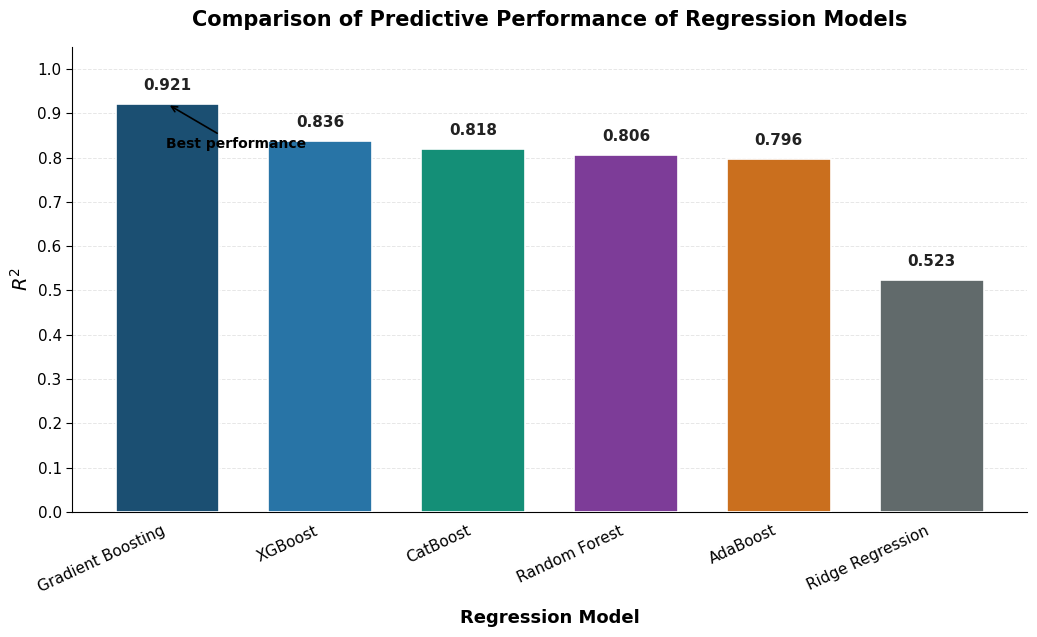

In [143]:
# =============================================================================
# Figure 4: Comparison of Six Regression Models Based on R²
# Publication-quality version
# =============================================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -----------------------------------------------------------------------------
# Six models included in the main regression comparison
# -----------------------------------------------------------------------------

six_models = [
    "Gradient Boosting",
    "XGBoost",
    "CatBoost",
    "Random Forest",
    "AdaBoost",
    "Ridge Regression"
]

# Select only the six models
figure4_df = results_df[
    results_df["Model"].isin(six_models)
].copy()

# Sort according to R² performance
figure4_df = figure4_df.sort_values(
    by="R²",
    ascending=False
)

# -----------------------------------------------------------------------------
# Publication-quality style
# -----------------------------------------------------------------------------

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

# -----------------------------------------------------------------------------
# Figure
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10.5, 6.5))

# Professional scientific color palette
colors = [
    "#1B4F72",   # Gradient Boosting - deep blue
    "#2874A6",   # XGBoost - blue
    "#148F77",   # CatBoost - teal
    "#7D3C98",   # Random Forest - purple
    "#CA6F1E",   # AdaBoost - orange
    "#616A6B"    # Ridge - gray
]

bars = ax.bar(
    figure4_df["Model"],
    figure4_df["R²"],
    color=colors,
    width=0.68,
    edgecolor="white",
    linewidth=1.2,
    zorder=3
)

# -----------------------------------------------------------------------------
# Add R² values above bars
# -----------------------------------------------------------------------------

for bar, value in zip(bars, figure4_df["R²"]):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.025,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color="#222222"
    )

# -----------------------------------------------------------------------------
# Axes
# -----------------------------------------------------------------------------

ax.set_ylabel(
    r"$R^2$",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "Regression Model",
    fontsize=13,
    fontweight="bold",
    labelpad=10
)

ax.set_title(
    "Comparison of Predictive Performance of Regression Models",
    fontsize=15,
    fontweight="bold",
    pad=15
)

# Y-axis range
ax.set_ylim(0, 1.05)

# Y-axis ticks
ax.set_yticks(np.arange(0, 1.01, 0.1))

# -----------------------------------------------------------------------------
# Grid
# -----------------------------------------------------------------------------

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.30,
    zorder=0
)

# No vertical grid
ax.grid(
    axis="x",
    visible=False
)

# -----------------------------------------------------------------------------
# X-axis formatting
# -----------------------------------------------------------------------------

ax.tick_params(
    axis="x",
    length=0,
    pad=8
)

ax.tick_params(
    axis="y",
    width=0.8,
    length=4
)

plt.xticks(
    rotation=25,
    ha="right"
)

# -----------------------------------------------------------------------------
# Remove unnecessary borders
# -----------------------------------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

# -----------------------------------------------------------------------------
# Add subtle annotation for best-performing model
# -----------------------------------------------------------------------------

best_model = figure4_df.iloc[0]["Model"]
best_r2 = figure4_df.iloc[0]["R²"]

ax.annotate(
    "Best performance",
    xy=(0, best_r2),
    xytext=(0.45, best_r2 - 0.10),
    fontsize=10,
    fontweight="bold",
    ha="center",
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.2
    )
)

# -----------------------------------------------------------------------------
# Layout
# -----------------------------------------------------------------------------

plt.tight_layout()

# -----------------------------------------------------------------------------
# Save as high-resolution PNG
# -----------------------------------------------------------------------------

plt.savefig(
    "Figure_4_Model_Performance_R2.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

# -----------------------------------------------------------------------------
# Save as vector PDF for journal submission
# -----------------------------------------------------------------------------

plt.savefig(
    "Figure_4_Model_Performance_R2.pdf",
    format="pdf",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

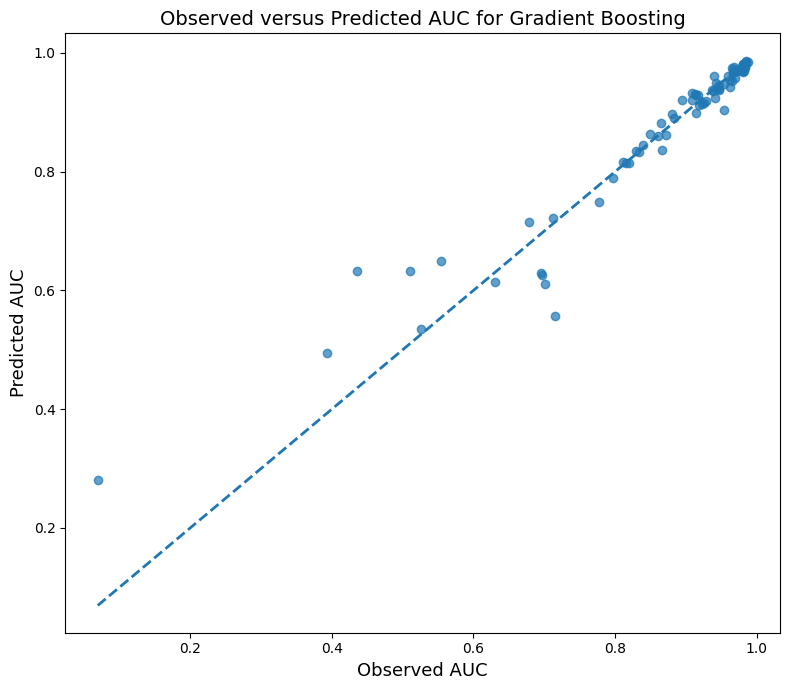

In [128]:
# =============================================================================
# Figure 5: Observed versus Predicted AUC - Gradient Boosting
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np

# Best Gradient Boosting model
best_gb = gb_grid.best_estimator_

# Predictions on unseen test set
y_pred_gb = best_gb.predict(X_test)

# Plot
plt.figure(figsize=(8, 7))

plt.scatter(
    y_test,
    y_pred_gb,
    alpha=0.7
)

# Identity line
min_val = min(y_test.min(), y_pred_gb.min())
max_val = max(y_test.max(), y_pred_gb.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--',
    linewidth=2
)

plt.xlabel("Observed AUC", fontsize=13)
plt.ylabel("Predicted AUC", fontsize=13)

plt.title(
    "Observed versus Predicted AUC for Gradient Boosting",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    "Figure_5_Observed_vs_Predicted_AUC.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

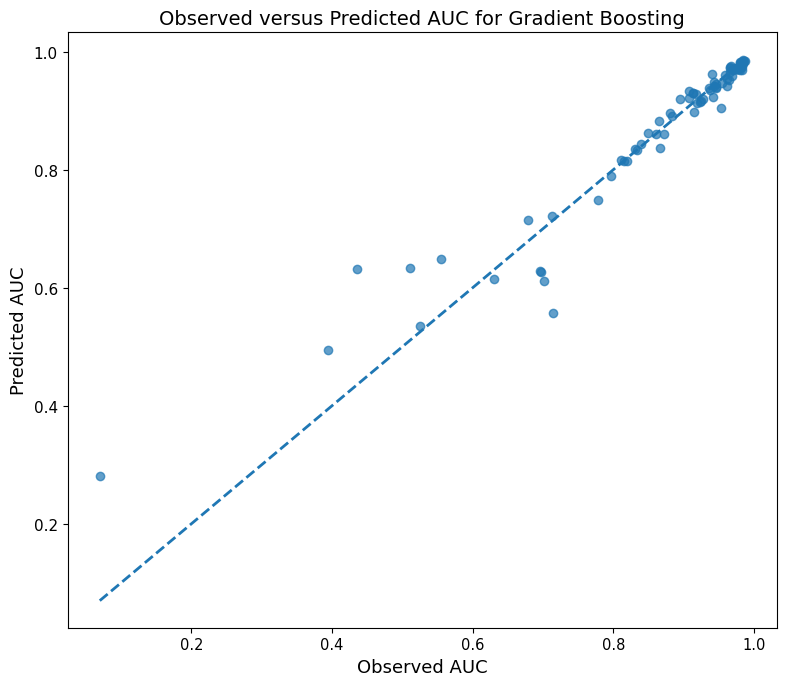

<Figure size 640x480 with 0 Axes>

In [163]:
# =============================================================================
# Figure 5: Observed versus Predicted AUC - Gradient Boosting
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np

# Best Gradient Boosting model
best_gb = gb_grid.best_estimator_

# Predictions on unseen test set
y_pred_gb = best_gb.predict(X_test)

# Plot
plt.figure(figsize=(8, 7))

plt.scatter(
    y_test,
    y_pred_gb,
    alpha=0.7
)

# Identity line
min_val = min(y_test.min(), y_pred_gb.min())
max_val = max(y_test.max(), y_pred_gb.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--',
    linewidth=2
)

plt.xlabel("Observed AUC", fontsize=13)
plt.ylabel("Predicted AUC", fontsize=13)

plt.title(
    "Observed versus Predicted AUC for Gradient Boosting",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    "Figure_5_Observed_vs_Predicted_AUC.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
# Save as PDF
plt.savefig(
    "Figure_5_Observed_vs_Predicted_AUC.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

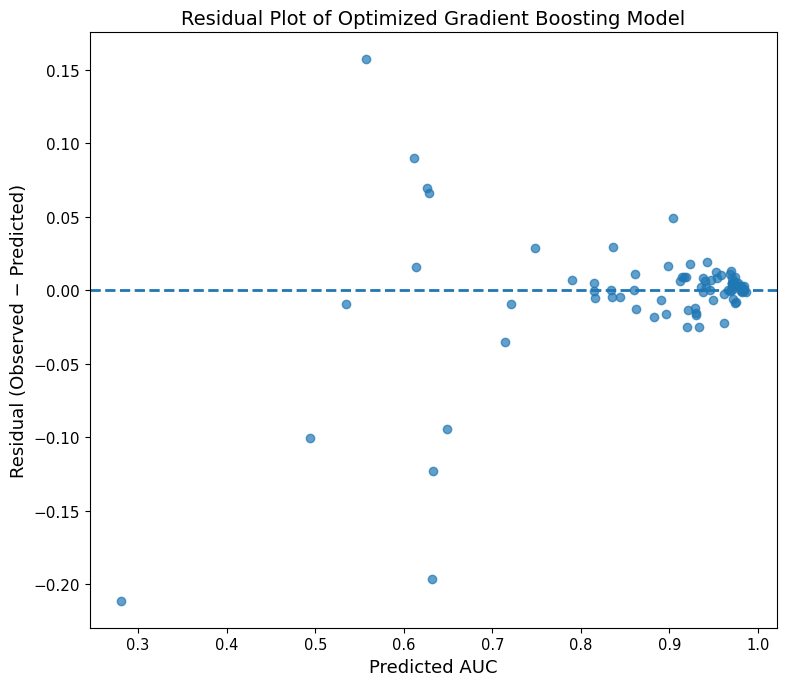

In [164]:
# =============================================================================
# Figure 6: Residual Analysis - Gradient Boosting
# =============================================================================

# Calculate residuals
residuals_gb = y_test - y_pred_gb

# Plot residuals against predicted AUC
plt.figure(figsize=(8, 7))

plt.scatter(
    y_pred_gb,
    residuals_gb,
    alpha=0.7
)

# Zero-residual reference line
plt.axhline(
    y=0,
    linestyle='--',
    linewidth=2
)

plt.xlabel("Predicted AUC", fontsize=13)
plt.ylabel("Residual (Observed − Predicted)", fontsize=13)

plt.title(
    "Residual Plot of Optimized Gradient Boosting Model",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    "Figure_6_Residual_Plot_Gradient_Boosting.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

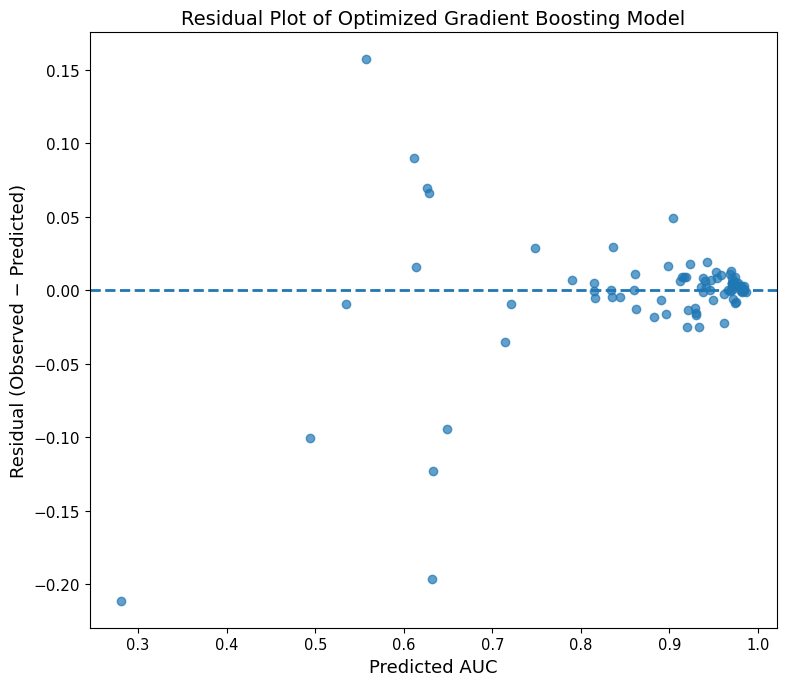

In [156]:
# =============================================================================
# Figure 6: Residual Analysis - Gradient Boosting
# =============================================================================

# Calculate residuals
residuals_gb = y_test - y_pred_gb

# Plot residuals against predicted AUC
plt.figure(figsize=(8, 7))

plt.scatter(
    y_pred_gb,
    residuals_gb,
    alpha=0.7
)

# Zero-residual reference line
plt.axhline(
    y=0,
    linestyle='--',
    linewidth=2
)

plt.xlabel("Predicted AUC", fontsize=13)
plt.ylabel("Residual (Observed − Predicted)", fontsize=13)

plt.title(
    "Residual Plot of Optimized Gradient Boosting Model",
    fontsize=14
)

plt.tight_layout()

# Save as PDF
plt.savefig(
    "Figure_6_Residual_Plot_Gradient_Boosting.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

    Feature  Importance
0      ic50    0.743407
1  max conc    0.216605
2      rmse    0.022475
3   z score    0.017512


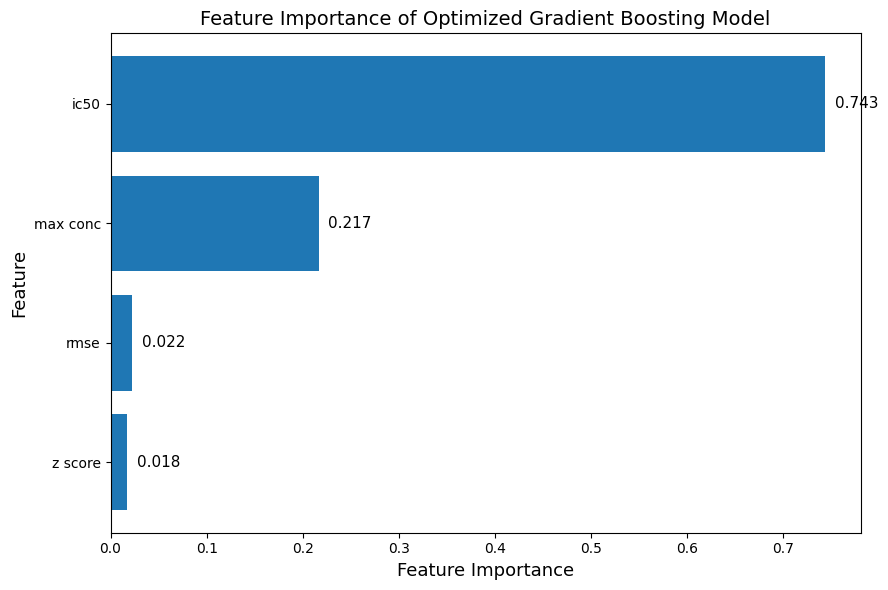

In [132]:
# =============================================================================
# Figure 7: Feature Importance of Optimized Gradient Boosting Model
# =============================================================================

import matplotlib.pyplot as plt
import pandas as pd

best_gb = gb_grid.best_estimator_

# Extract feature importance from the Gradient Boosting step
feature_importance = best_gb.named_steps['model'].feature_importances_

# Feature names
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)

plt.figure(figsize=(9, 6))

bars = plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.gca().invert_yaxis()

for bar, value in zip(bars, importance_df['Importance']):
    plt.text(
        value + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.3f}',
        va='center',
        fontsize=11
    )

plt.xlabel('Feature Importance', fontsize=13)
plt.ylabel('Feature', fontsize=13)

plt.title(
    'Feature Importance of Optimized Gradient Boosting Model',
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    'Figure_7_Gradient_Boosting_Feature_Importance.png',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

    Feature  Importance
0      ic50    0.743407
1  max conc    0.216605
2      rmse    0.022475
3   z score    0.017512


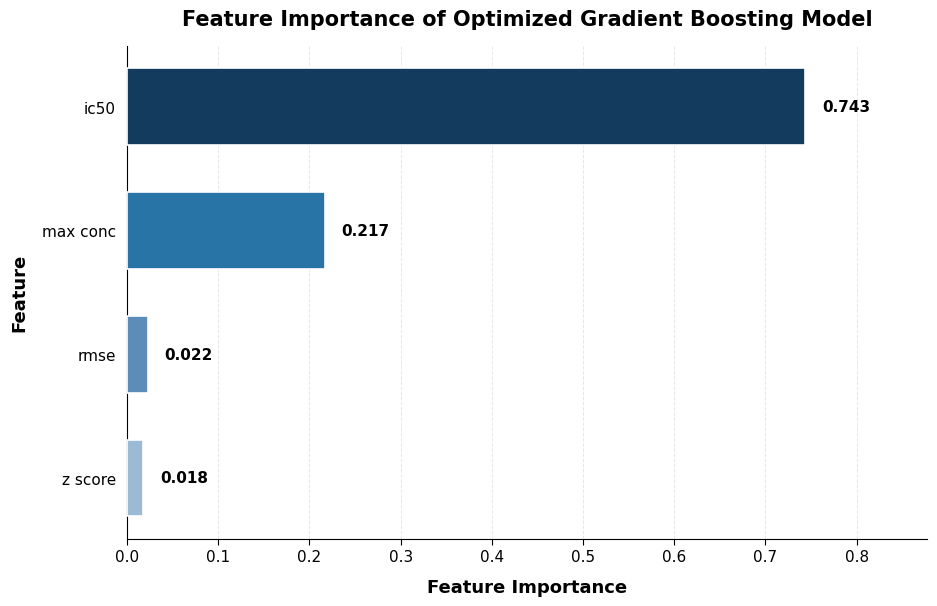

In [145]:
# =============================================================================
# Figure 7: Feature Importance of Optimized Gradient Boosting Model
# Publication-quality version
# =============================================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -----------------------------------------------------------------------------
# Extract optimized Gradient Boosting model
# -----------------------------------------------------------------------------

best_gb = gb_grid.best_estimator_

feature_importance = best_gb.named_steps["model"].feature_importances_

feature_names = X_train.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

# Sort from highest to lowest
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print(importance_df)

# -----------------------------------------------------------------------------
# Publication-quality settings
# -----------------------------------------------------------------------------

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

# -----------------------------------------------------------------------------
# Create figure
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9.5, 6.2))

# -----------------------------------------------------------------------------
# Professional color palette
# -----------------------------------------------------------------------------

colors = [
    "#123B5D",   # IC50 - strongest
    "#2874A6",   # Max Conc
    "#5B8DB8",   # RMSE
    "#9BBBD4"    # Z score
]

# -----------------------------------------------------------------------------
# Horizontal bar plot
# -----------------------------------------------------------------------------

bars = ax.barh(
    importance_df["Feature"],
    importance_df["Importance"],
    color=colors,
    height=0.62,
    edgecolor="white",
    linewidth=1.2,
    zorder=3
)

# Highest importance at top
ax.invert_yaxis()

# -----------------------------------------------------------------------------
# Add numerical values
# -----------------------------------------------------------------------------

max_importance = importance_df["Importance"].max()

for bar, value in zip(
    bars,
    importance_df["Importance"]
):

    ax.text(
        value + max_importance * 0.025,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        ha="left",
        fontsize=11,
        fontweight="bold"
    )

# -----------------------------------------------------------------------------
# Labels
# -----------------------------------------------------------------------------

ax.set_xlabel(
    "Feature Importance",
    fontsize=13,
    fontweight="bold",
    labelpad=10
)

ax.set_ylabel(
    "Feature",
    fontsize=13,
    fontweight="bold",
    labelpad=10
)

ax.set_title(
    "Feature Importance of Optimized Gradient Boosting Model",
    fontsize=15,
    fontweight="bold",
    pad=15
)

# -----------------------------------------------------------------------------
# X-axis
# -----------------------------------------------------------------------------

ax.set_xlim(
    0,
    max_importance * 1.18
)

ax.set_xticks(
    np.arange(0, 0.81, 0.1)
)

# -----------------------------------------------------------------------------
# Grid
# -----------------------------------------------------------------------------

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.7,
    alpha=0.30,
    zorder=0
)

ax.grid(
    axis="y",
    visible=False
)

# -----------------------------------------------------------------------------
# Tick formatting
# -----------------------------------------------------------------------------

ax.tick_params(
    axis="y",
    length=0,
    pad=8
)

ax.tick_params(
    axis="x",
    length=4,
    width=0.8
)

# -----------------------------------------------------------------------------
# Remove unnecessary borders
# -----------------------------------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

# -----------------------------------------------------------------------------
# Layout
# -----------------------------------------------------------------------------

plt.tight_layout()

# -----------------------------------------------------------------------------
# Save high-resolution PNG
# -----------------------------------------------------------------------------

plt.savefig(
    "Figure_7_Gradient_Boosting_Feature_Importance.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

# -----------------------------------------------------------------------------
# Save vector PDF
# -----------------------------------------------------------------------------

plt.savefig(
    "Figure_7_Gradient_Boosting_Feature_Importance.pdf",
    format="pdf",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

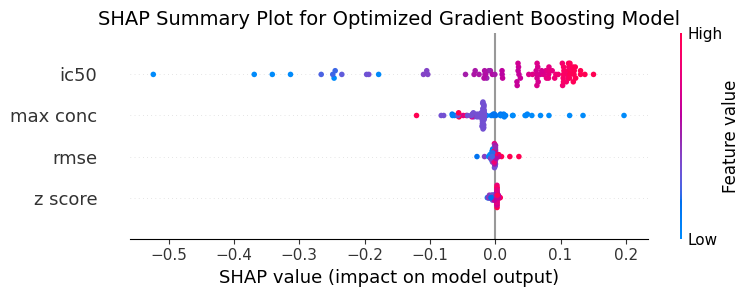

In [157]:
# =============================================================================
# Figure 8: SHAP Summary Plot for Optimized Gradient Boosting Model
# =============================================================================

import shap
import matplotlib.pyplot as plt

# Get the best tuned pipeline
best_gb = gb_grid.best_estimator_

# Extract the actual Gradient Boosting model from the pipeline
gb_model = best_gb.named_steps['model']

# Create SHAP TreeExplainer using the actual tree model
explainer = shap.TreeExplainer(gb_model)

# Apply the same preprocessing used by the pipeline
X_test_scaled = best_gb.named_steps['scaler'].transform(X_test)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_scaled)

# SHAP summary plot
plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X_test.columns,
    show=False
)

plt.title(
    'SHAP Summary Plot for Optimized Gradient Boosting Model',
    fontsize=14
)

plt.tight_layout()

# Save as PDF
plt.savefig(
    'Figure_8_SHAP_Gradient_Boosting.pdf',
    format='pdf',
    bbox_inches='tight'
)

plt.show()

In [58]:
# =============================================================================
# Linear Regression
# =============================================================================

best_model = models['Linear Regression']

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print("Linear Regression")
print("---------------------------")
print("R² :", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))



# =============================================================================
# Ridge Regression
# =============================================================================

best_model = models['Ridge Regression']

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print("Ridge Regression")
print("---------------------------")
print("R² :", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))



# =============================================================================
# Lasso Regression
# =============================================================================

best_model = models['Lasso Regression']


best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print("Lasso Regression")
print("---------------------------")
print("R² :", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))



Linear Regression
---------------------------
R² : 0.2030223495271507
MSE: 0.019764911333367944
MAE: 0.06536583843419226
Ridge Regression
---------------------------
R² : 0.21484917878683973
MSE: 0.019471607962145494
MAE: 0.06517743729199967
Lasso Regression
---------------------------
R² : -0.0006342549868165737
MSE: 0.024815560781674496
MAE: 0.1065550809592723


In [61]:
# =============================================================================
# Evaluate All Models on the Unseen Test Set
# =============================================================================

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pandas as pd

best_models = {
    "Linear Regression": models['Linear Regression'],
    "Ridge Regression": models['Ridge Regression'],
    "Lasso Regression": models['Lasso Regression'],
    "Random Forest": rf_grid.best_estimator_,
    "AdaBoost": ada_grid.best_estimator_,
    "Gradient Boosting": gb_grid.best_estimator_
}

results = []

for name, model in best_models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "R²": r2_score(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

print(results_df.sort_values(by="R²", ascending=False))



               Model        R²       MSE       MAE
5  Gradient Boosting  0.920577  0.001970  0.020504
3      Random Forest  0.806262  0.004805  0.027164
4           AdaBoost  0.795962  0.005060  0.036792
1   Ridge Regression  0.214849  0.019472  0.065177
0  Linear Regression  0.203022  0.019765  0.065366
2   Lasso Regression -0.000634  0.024816  0.106555


# Evaluation Metrics R², MSE, MAE,RMSE,MAPE

# Plots

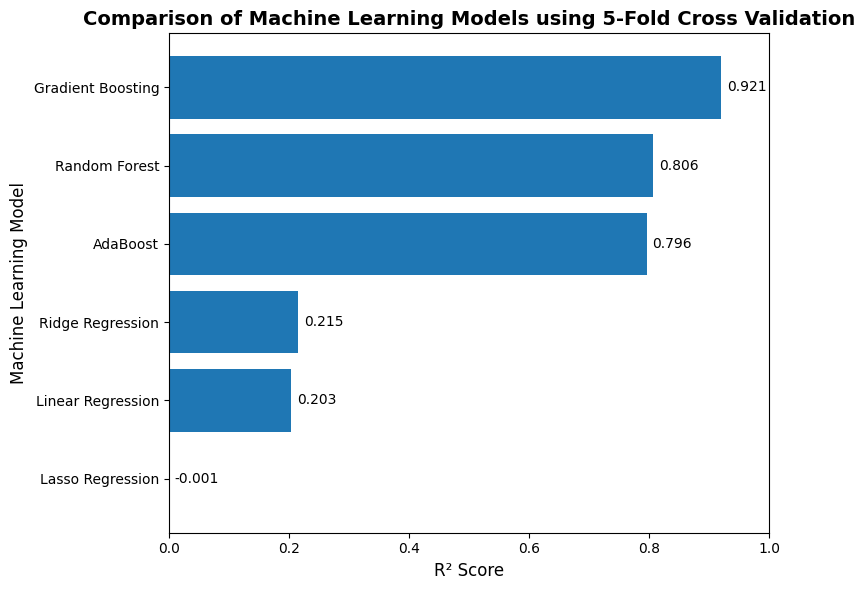

In [64]:
# =============================================================================
# Model Comparison Plot (R²)
# =============================================================================

import matplotlib.pyplot as plt

# Sort models by R²
results_sorted = results_df.sort_values(
    by='R²',
    ascending=True
)

plt.figure(figsize=(8,6))

plt.barh(
    results_sorted['Model'],
    results_sorted['R²']
)

plt.xlabel('R² Score', fontsize=12)

plt.ylabel('Machine Learning Model', fontsize=12)

plt.title(
    'Comparison of Machine Learning Models using 5-Fold Cross Validation',
    fontsize=14,
    fontweight='bold'
)

# Display R² values on bars
for index, value in enumerate(results_sorted['R²']):
    plt.text(
        value + 0.01,
        index,
        f'{value:.3f}',
        va='center',
        fontsize=10
    )

plt.xlim(0,1)

plt.tight_layout()

plt.show()

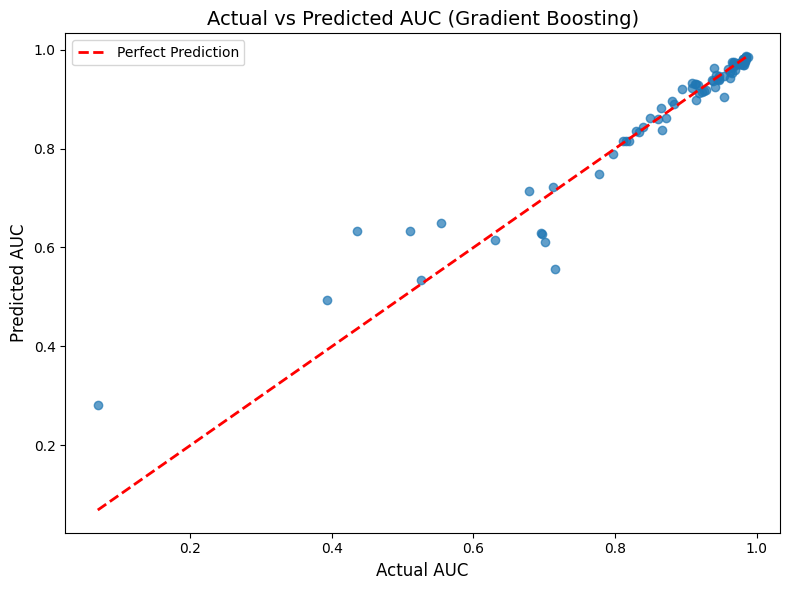

In [65]:
# =============================================================================
# Predicted vs Actual Scatter Plot
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))

# Scatter plot
plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

# Perfect prediction reference line (45° line)
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    'r--',
    linewidth=2,
    label='Perfect Prediction'
)

plt.xlabel('Actual AUC', fontsize=12)
plt.ylabel('Predicted AUC', fontsize=12)
plt.title('Actual vs Predicted AUC (Gradient Boosting)', fontsize=14)

plt.legend()

plt.tight_layout()

plt.show()

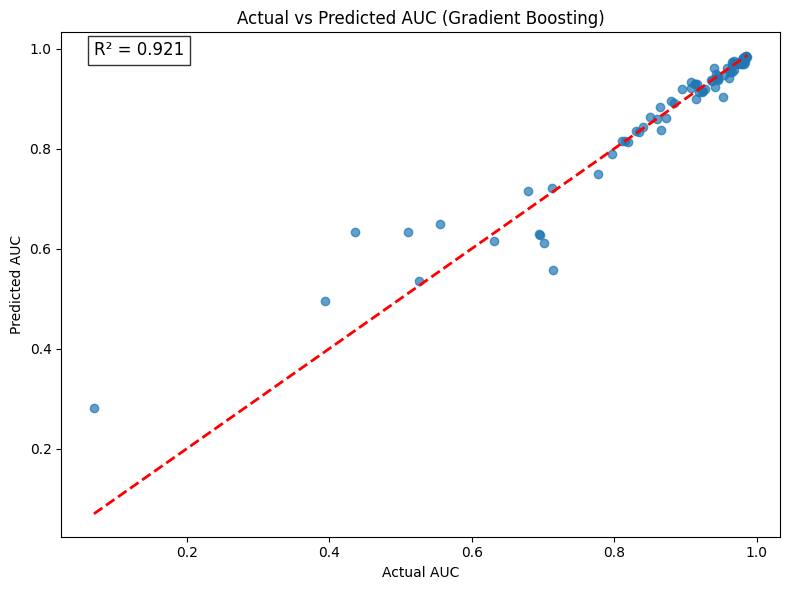

In [66]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    'r--',
    linewidth=2
)

plt.text(
    min_value,
    max_value,
    f'R² = {r2:.3f}',
    fontsize=12,
    bbox=dict(facecolor='white', alpha=0.8)
)

plt.xlabel("Actual AUC")
plt.ylabel("Predicted AUC")
plt.title("Actual vs Predicted AUC (Gradient Boosting)")

plt.tight_layout()

plt.show()

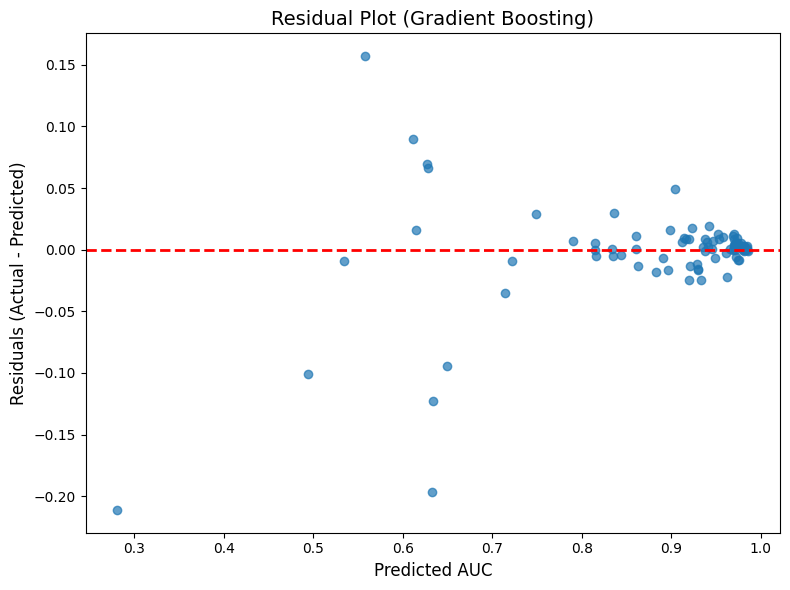

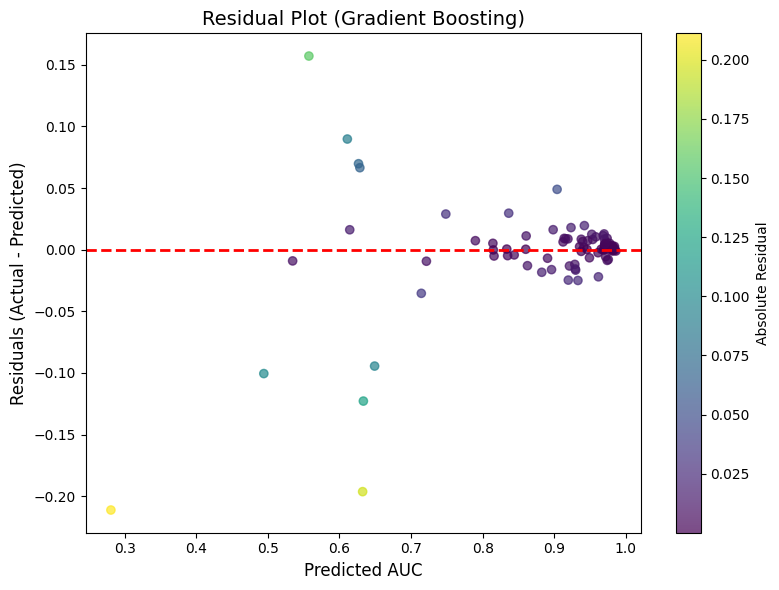

In [67]:
# =============================================================================
# Calculate Residuals
# =============================================================================

# Best Gradient Boosting model
best_model = gb_grid.best_estimator_

# Train the model
best_model.fit(X_train, y_train)

# Predict on unseen test data
y_pred = best_model.predict(X_test)

# Calculate residuals
residuals = y_test - y_pred

# =============================================================================
# Residual Plot
# =============================================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Scatter plot of predicted values vs residuals
plt.scatter(
    y_pred,
    residuals,
    alpha=0.7
)

# Horizontal reference line at zero residual
plt.axhline(
    y=0,
    color='red',
    linestyle='--',
    linewidth=2
)

plt.xlabel("Predicted AUC", fontsize=12)
plt.ylabel("Residuals (Actual - Predicted)", fontsize=12)
plt.title("Residual Plot (Gradient Boosting)", fontsize=14)

plt.tight_layout()

plt.show()

# =============================================================================
# Residual Plot with Color Scale
# =============================================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    y_pred,
    residuals,
    c=abs(residuals),
    alpha=0.7
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--',
    linewidth=2
)

plt.colorbar(scatter, label='Absolute Residual')

plt.xlabel("Predicted AUC", fontsize=12)
plt.ylabel("Residuals (Actual - Predicted)", fontsize=12)
plt.title("Residual Plot (Gradient Boosting)", fontsize=14)

plt.tight_layout()

plt.show()

    Feature  Importance
0      ic50    0.743407
1  max conc    0.216605
2      rmse    0.022475
3   z score    0.017512


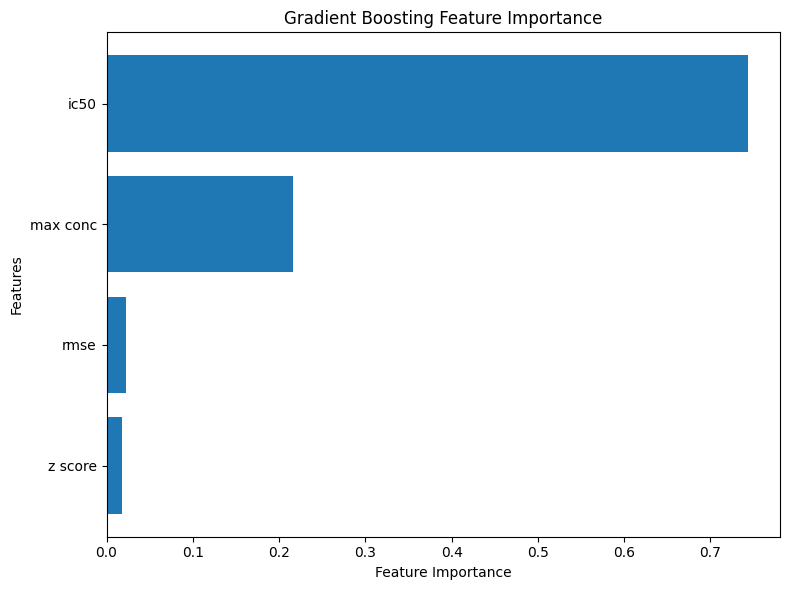

In [68]:
# =============================================================================
# Feature Importance - Gradient Boosting
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt

# Best tuned Gradient Boosting model
best_model = gb_grid.best_estimator_

# Train model
best_model.fit(X_train, y_train)

# Extract Gradient Boosting model from Pipeline
gb_model = best_model.named_steps['model']

# Get feature importance scores
importance = gb_model.feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

# Plot
plt.figure(figsize=(8,6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Feature Importance')

plt.ylabel('Features')

plt.title('Gradient Boosting Feature Importance')

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

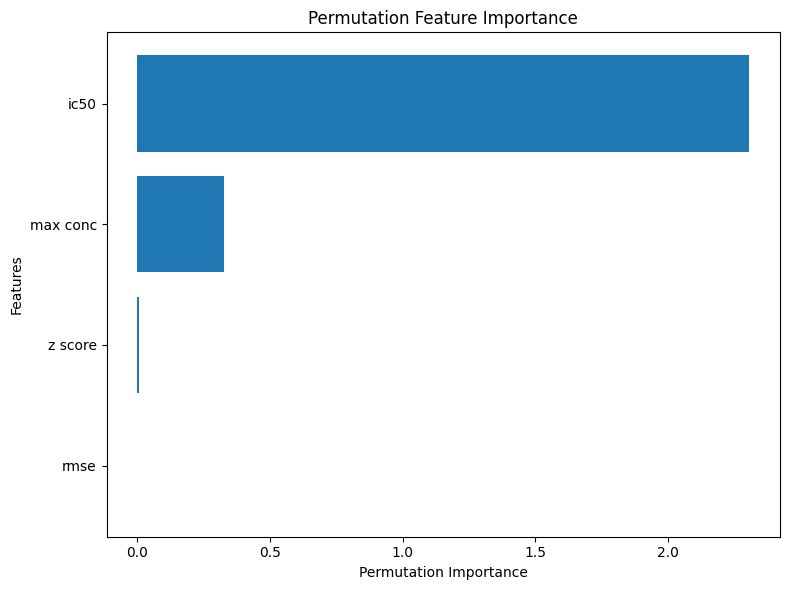

In [69]:
# =============================================================================
# Permutation Feature Importance
# =============================================================================

from sklearn.inspection import permutation_importance

result = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring='r2',
    n_repeats=20,
    random_state=42
)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(8,6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.xlabel("Permutation Importance")

plt.ylabel("Features")

plt.title("Permutation Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

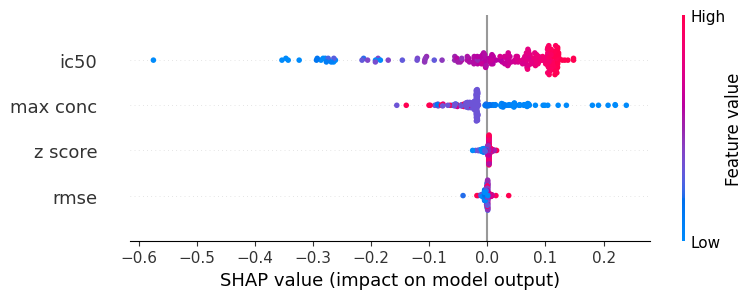

In [82]:
# =============================================================================
# SHAP Feature Importance
# =============================================================================

import shap

# Extract trained Gradient Boosting model
gb_model = best_model.named_steps['model']

# Scale training data using the fitted scaler
scaler = best_model.named_steps['scaler']
X_train_scaled = scaler.transform(X_train)

# Create SHAP explainer
explainer = shap.TreeExplainer(gb_model)

# Compute SHAP values
shap_values = explainer.shap_values(X_train_scaled)

# Summary plot
shap.summary_plot(
    shap_values,
    X_train_scaled,
    feature_names=X.columns
)

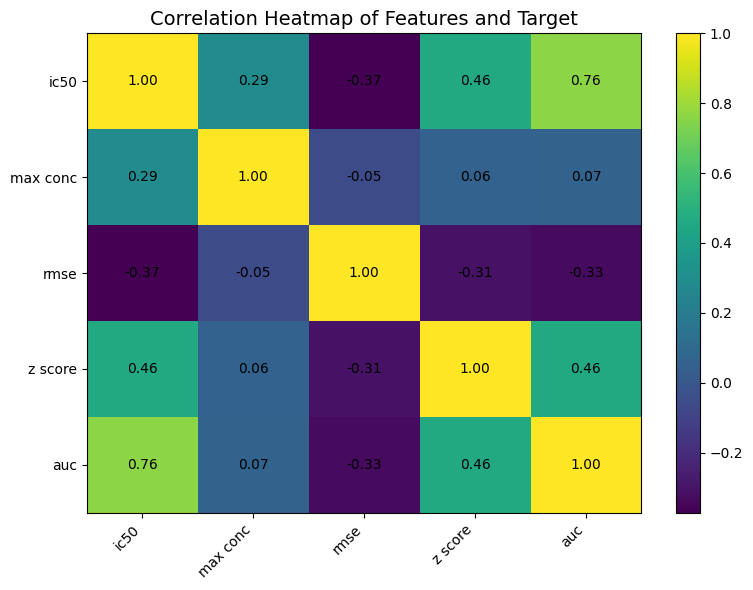

In [73]:
# =============================================================================
# Correlation Heatmap
# =============================================================================

# Select features and target
correlation_data = gbm_data[
    ['ic50', 'max conc', 'rmse', 'z score', 'auc']
]

# Calculate correlation matrix
corr_matrix = correlation_data.corr()

# Create figure
plt.figure(figsize=(8,6))

# Plot heatmap
image = plt.imshow(
    corr_matrix,
    interpolation='nearest',
    aspect='auto'
)

# Color bar
plt.colorbar(image)

# Tick labels
plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

# Display correlation values
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha='center',
            va='center',
            fontsize=10
        )

plt.title("Correlation Heatmap of Features and Target", fontsize=14)

plt.tight_layout()

plt.show()

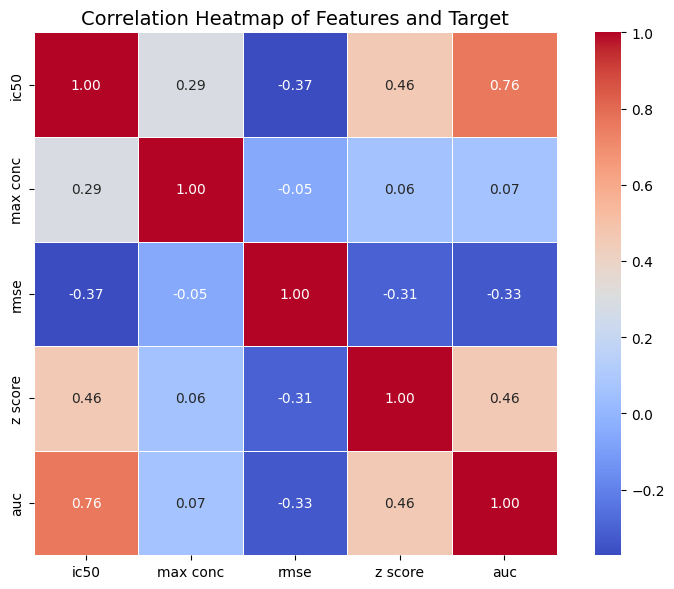

In [74]:
# =============================================================================
# Correlation Heatmap (Seaborn)
# =============================================================================

# Select features and target
correlation_data = gbm_data[
    ['ic50', 'max conc', 'rmse', 'z score', 'auc']
]

# Calculate correlation matrix
corr_matrix = correlation_data.corr()

# Plot heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap of Features and Target", fontsize=14)

plt.tight_layout()

plt.show()

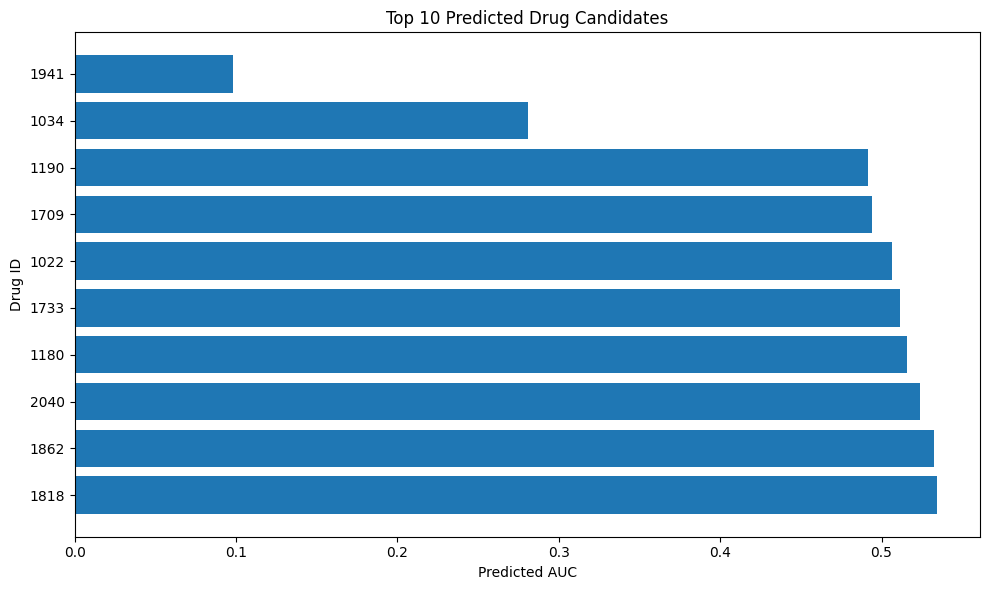

In [75]:
# =============================================================================
# Drug Ranking using Predicted AUC
# =============================================================================

import matplotlib.pyplot as plt
import pandas as pd

# Best tuned model
best_model = gb_grid.best_estimator_

# Train model
best_model.fit(X_train, y_train)

# Predict AUC for the entire dataset
predicted_auc = best_model.predict(X)

# Create results table
drug_ranking = pd.DataFrame({
    'Drug ID': gbm_data['drug id'],
    'Predicted AUC': predicted_auc
})

# Remove duplicate Drug IDs (optional)
drug_ranking = drug_ranking.groupby(
    'Drug ID',
    as_index=False
)['Predicted AUC'].mean()

# Lowest AUC = highest sensitivity
drug_ranking = drug_ranking.sort_values(
    by='Predicted AUC',
    ascending=True
)

top10 = drug_ranking.head(10)

# Plot
plt.figure(figsize=(10,6))

plt.barh(
    top10['Drug ID'].astype(str),
    top10['Predicted AUC']
)

plt.xlabel("Predicted AUC")
plt.ylabel("Drug ID")
plt.title("Top 10 Predicted Drug Candidates")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

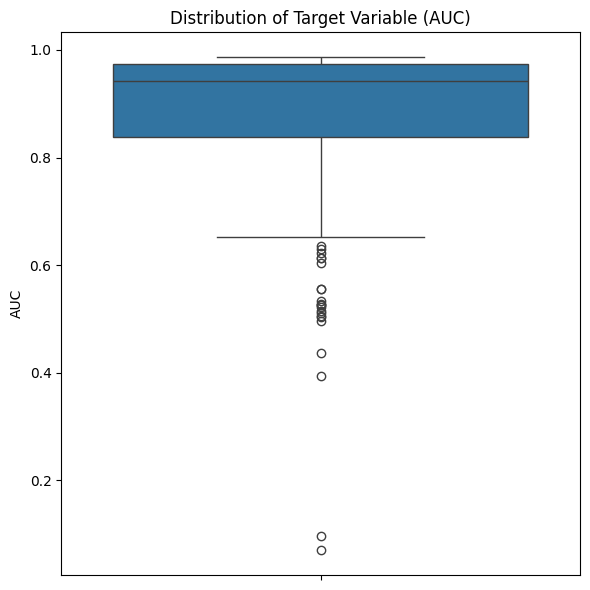

In [77]:
# =============================================================================
# Boxplot of Target Variable
# =============================================================================


plt.figure(figsize=(6,6))

sns.boxplot(
    y=gbm_data['auc']
)

plt.ylabel("AUC")

plt.title("Distribution of Target Variable (AUC)")

plt.tight_layout()

plt.show()

In [84]:
gbm_data[['ic50','auc']].corr()

,ic50,auc
ic50,1.00000,0.76393
auc,0.76393,1.00000


# CatBoost XgBoost

In [90]:
# =============================================================================
# CatBoost Regression Model
# =============================================================================

catboost_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    random_seed=42,
    verbose=0
)

In [91]:
# =============================================================================
# Evaluate CatBoost using 5-Fold Cross Validation
# =============================================================================

catboost_scores = cross_validate(

    estimator=catboost_model,

    X=X,

    y=y,

    cv=kf,

    scoring={
        'R2': 'r2',
        'MSE': 'neg_mean_squared_error',
        'RMSE': 'neg_root_mean_squared_error',
        'MAE': 'neg_mean_absolute_error'
    },

    return_train_score=False
)

catboost_r2 = catboost_scores['test_R2'].mean()

catboost_mse = -catboost_scores['test_MSE'].mean()

catboost_rmse = -catboost_scores['test_RMSE'].mean()

catboost_mae = -catboost_scores['test_MAE'].mean()

print("CatBoost - 5-Fold Cross Validation")
print("-----------------------------------")
print("R²   :", catboost_r2)
print("MSE  :", catboost_mse)
print("RMSE :", catboost_rmse)
print("MAE  :", catboost_mae)

CatBoost - 5-Fold Cross Validation
-----------------------------------
R²   : 0.8797726511943935
MSE  : 0.00256579738610458
RMSE : 0.04674525143362686
MAE  : 0.019279881684244177


In [92]:
# =============================================================================
# XGBoost Regression Model
# =============================================================================

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    objective='reg:squarederror',
    random_state=42
)

In [93]:
# =============================================================================
# Evaluate XGBoost using 5-Fold Cross Validation
# =============================================================================

xgb_scores = cross_validate(

    estimator=xgb_model,

    X=X,

    y=y,

    cv=kf,

    scoring={
        'R2': 'r2',
        'MSE': 'neg_mean_squared_error',
        'RMSE': 'neg_root_mean_squared_error',
        'MAE': 'neg_mean_absolute_error'
    },

    return_train_score=False
)

xgb_r2 = xgb_scores['test_R2'].mean()

xgb_mse = -xgb_scores['test_MSE'].mean()

xgb_rmse = -xgb_scores['test_RMSE'].mean()

xgb_mae = -xgb_scores['test_MAE'].mean()

print("XGBoost - 5-Fold Cross Validation")
print("----------------------------------")
print("R²   :", xgb_r2)
print("MSE  :", xgb_mse)
print("RMSE :", xgb_rmse)
print("MAE  :", xgb_mae)

XGBoost - 5-Fold Cross Validation
----------------------------------
R²   : 0.8675480735521252
MSE  : 0.002705740045695598
RMSE : 0.049997411348055874
MAE  : 0.021045960509503144


In [94]:
# =============================================================================
# Compare CatBoost and XGBoost
# =============================================================================

comparison = pd.DataFrame({

    'Model': [
        'CatBoost',
        'XGBoost'
    ],

    'R² Mean': [
        catboost_r2,
        xgb_r2
    ],

    'MSE Mean': [
        catboost_mse,
        xgb_mse
    ],

    'RMSE Mean': [
        catboost_rmse,
        xgb_rmse
    ],

    'MAE Mean': [
        catboost_mae,
        xgb_mae
    ]
})

comparison

,Model,R² Mean,MSE Mean,RMSE Mean,MAE Mean
0,CatBoost,0.879773,0.002566,0.046745,0.019280
1,XGBoost,0.867548,0.002706,0.049997,0.021046


In [106]:
# =============================================================================
# Evaluate All Models on the Unseen Test Set
# =============================================================================

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pandas as pd

best_models = {
    "Linear Regression": models['Linear Regression'],
    "Ridge Regression": best_ridge,
    "Lasso Regression": models['Lasso Regression'],
    "Random Forest": rf_grid.best_estimator_,
    "AdaBoost": ada_grid.best_estimator_,
    "Gradient Boosting": gb_grid.best_estimator_,
    "CatBoost": catboost_model,
    "XGBoost": xgb_model
}

results = []

for name, model in best_models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "R²": r2_score(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": mean_squared_error(y_test, y_pred) ** 0.5,
        "MAE": mean_absolute_error(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R²",
    ascending=False
).reset_index(drop=True)

print(results_df)

               Model        R²       MSE      RMSE       MAE
0  Gradient Boosting  0.920577  0.001970  0.044381  0.020504
1            XGBoost  0.836444  0.004056  0.063688  0.025946
2           CatBoost  0.818369  0.004504  0.067115  0.026117
3      Random Forest  0.806262  0.004805  0.069316  0.027164
4           AdaBoost  0.795962  0.005060  0.071134  0.036792
5   Ridge Regression  0.522718  0.011837  0.108796  0.064951
6  Linear Regression  0.203022  0.019765  0.140588  0.065366
7   Lasso Regression -0.000634  0.024816  0.157530  0.106555


# Stacking

In [110]:
# =============================================================================
# 1. Define the Six Base Models
# =============================================================================

base_models = {

    "Gradient Boosting":
        gb_grid.best_estimator_,

    "XGBoost":
        xgb_model,

    "CatBoost":
        catboost_model,

    "Random Forest":
        rf_grid.best_estimator_,

    "AdaBoost":
        ada_grid.best_estimator_,

    "Ridge Regression":
        best_ridge
}



n_train = len(X_train)
n_test = len(X_test)
n_models = len(base_models)

oof_predictions = np.zeros(
    (n_train, n_models)
)

test_predictions = np.zeros(
    (n_test, n_models)
)


# Store model names in a fixed order
model_names = list(base_models.keys())


# =============================================================================
# 4. Generate Out-of-Fold Predictions
# =============================================================================

for model_index, (model_name, model) in enumerate(
    base_models.items()
):

    print("\nProcessing:", model_name)

    for fold, (train_index, valid_index) in enumerate(
        kf.split(X_train),
        start=1
    ):

        # ---------------------------------------------------------
        # Split training data into current fold
        # ---------------------------------------------------------

        X_fold_train = X_train.iloc[train_index]
        X_fold_valid = X_train.iloc[valid_index]

        y_fold_train = y_train.iloc[train_index]
        y_fold_valid = y_train.iloc[valid_index]


        # ---------------------------------------------------------
        # Clone model to ensure independent training
        # ---------------------------------------------------------

        fold_model = clone(model)


        # ---------------------------------------------------------
        # Train model on 4 folds
        # ---------------------------------------------------------

        fold_model.fit(
            X_fold_train,
            y_fold_train
        )


        # ---------------------------------------------------------
        # Predict the completely held-out fold
        # ---------------------------------------------------------

        oof_predictions[
            valid_index,
            model_index
        ] = fold_model.predict(
            X_fold_valid
        )


        print(
            f"    Fold {fold}: completed"
        )


    # =========================================================================
    # 5. Retrain Base Model on Entire Training Dataset
    # =========================================================================

    final_model = clone(model)

    final_model.fit(
        X_train,
        y_train
    )


    # =========================================================================
    # 6. Generate Predictions for Unseen Test Set
    # =========================================================================

    test_predictions[
        :,
        model_index
    ] = final_model.predict(
        X_test
    )


# =============================================================================
# 7. Create OOF Prediction DataFrame
# =============================================================================

oof_df = pd.DataFrame(
    oof_predictions,
    columns=model_names,
    index=X_train.index
)


# =============================================================================
# 8. Create Test Prediction DataFrame
# =============================================================================

test_pred_df = pd.DataFrame(
    test_predictions,
    columns=model_names,
    index=X_test.index
)


# =============================================================================
# 9. Check for Missing OOF Predictions
# =============================================================================

print("\nMissing OOF predictions:")
print(oof_df.isnull().sum())


# =============================================================================
# 10. Define Meta-Learner
# =============================================================================

# RidgeCV is used as the meta-learner because predictions from
# different base learners can be highly correlated.
#
# Standardization makes the meta-level coefficients comparable.

meta_learner = Pipeline([

    (
        "scaler",
        StandardScaler()
    ),

    (
        "ridge",
        RidgeCV(
            alphas=np.logspace(
                -4,
                4,
                50
            ),
            cv=5,
            scoring="r2"
        )
    )
])


# =============================================================================
# 11. Train Meta-Learner Using ONLY OOF Predictions
# =============================================================================

meta_learner.fit(
    oof_predictions,
    y_train
)


# =============================================================================
# 12. Predict AUC on the Unseen Test Set
# =============================================================================

stacked_predictions = meta_learner.predict(
    test_predictions
)


# =============================================================================
# 13. Evaluate Stacking Ensemble
# =============================================================================

stacking_r2 = r2_score(
    y_test,
    stacked_predictions
)

stacking_mse = mean_squared_error(
    y_test,
    stacked_predictions
)

stacking_rmse = np.sqrt(
    stacking_mse
)

stacking_mae = mean_absolute_error(
    y_test,
    stacked_predictions
)


# =============================================================================
# 14. Display Stacking Performance
# =============================================================================

print("\n" + "=" * 60)
print("STACKING ENSEMBLE - UNSEEN TEST SET")
print("=" * 60)

print(
    f"R²   : {stacking_r2:.6f}"
)

print(
    f"MSE  : {stacking_mse:.6f}"
)

print(
    f"RMSE : {stacking_rmse:.6f}"
)

print(
    f"MAE  : {stacking_mae:.6f}"
)


# =============================================================================
# 15. Identify Selected Meta-Learner Alpha
# =============================================================================

best_meta_alpha = (
    meta_learner
    .named_steps["ridge"]
    .alpha_
)

print(
    f"\nBest Meta-Learner Alpha: {best_meta_alpha}"
)


# =============================================================================
# 16. Meta-Learner Coefficients
# =============================================================================

meta_coefficients = pd.DataFrame({

    "Base Model": model_names,

    "Meta Coefficient":
        meta_learner
        .named_steps["ridge"]
        .coef_

})

meta_coefficients["Absolute Contribution"] = (
    meta_coefficients["Meta Coefficient"]
    .abs()
)

meta_coefficients = meta_coefficients.sort_values(
    by="Absolute Contribution",
    ascending=False
).reset_index(drop=True)


print("\nMeta-Learner Coefficients:")
print(meta_coefficients)


# =============================================================================
# 17. Create Final Model Comparison Table
# =============================================================================

stacking_result = pd.DataFrame({

    "Model": [
        "Stacking Ensemble"
    ],

    "R²": [
        stacking_r2
    ],

    "MSE": [
        stacking_mse
    ],

    "RMSE": [
        stacking_rmse
    ],

    "MAE": [
        stacking_mae
    ]
})


print("\nStacking Result:")
print(stacking_result)


Processing: Gradient Boosting
    Fold 1: completed
    Fold 2: completed
    Fold 3: completed
    Fold 4: completed
    Fold 5: completed

Processing: XGBoost
    Fold 1: completed
    Fold 2: completed
    Fold 3: completed
    Fold 4: completed
    Fold 5: completed

Processing: CatBoost
    Fold 1: completed
    Fold 2: completed
    Fold 3: completed
    Fold 4: completed
    Fold 5: completed

Processing: Random Forest
    Fold 1: completed
    Fold 2: completed
    Fold 3: completed
    Fold 4: completed
    Fold 5: completed

Processing: AdaBoost
    Fold 1: completed
    Fold 2: completed
    Fold 3: completed
    Fold 4: completed
    Fold 5: completed

Processing: Ridge Regression
    Fold 1: completed
    Fold 2: completed
    Fold 3: completed
    Fold 4: completed
    Fold 5: completed

Missing OOF predictions:
Gradient Boosting    0
XGBoost              0
CatBoost             0
Random Forest        0
AdaBoost             0
Ridge Regression     0
dtype: int64

STACKING 

In [111]:
# =============================================================================
# Final Model Comparison: 6 Models + Stacking Ensemble
# =============================================================================

selected_models = [
    "Gradient Boosting",
    "XGBoost",
    "CatBoost",
    "Random Forest",
    "AdaBoost",
    "Ridge Regression"
]

# Keep only the selected six models
results_df = results_df[
    results_df["Model"].isin(selected_models)
].copy()

# Add Stacking Ensemble
results_df = pd.concat(
    [
        results_df,
        stacking_result
    ],
    ignore_index=True
)

# Sort by R²
results_df = results_df.sort_values(
    by="R²",
    ascending=False
).reset_index(drop=True)

# Display final table
print(results_df)

               Model        R²       MSE      RMSE       MAE
0  Stacking Ensemble  0.923645  0.001894  0.043515  0.019116
1  Gradient Boosting  0.920577  0.001970  0.044381  0.020504
2            XGBoost  0.836444  0.004056  0.063688  0.025946
3           CatBoost  0.818369  0.004504  0.067115  0.026117
4      Random Forest  0.806262  0.004805  0.069316  0.027164
5           AdaBoost  0.795962  0.005060  0.071134  0.036792
6   Ridge Regression  0.522718  0.011837  0.108796  0.064951


In [114]:
# =============================================================================
# Leave-Cell-Line-Out Validation
# 5-Fold Hyperparameter Tuning within Each Training Fold
# =============================================================================

from sklearn.model_selection import LeaveOneGroupOut, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)
import numpy as np
import pandas as pd


# =============================================================================
# Define Cell-Line Groups
# =============================================================================

groups = gbm_data['cell line name']


# =============================================================================
# Leave-One-Cell-Line-Out Cross-Validation
# =============================================================================

logo = LeaveOneGroupOut()

logo_results = []

all_actual = []
all_predicted = []
all_cell_lines = []


for fold, (train_idx, test_idx) in enumerate(
    logo.split(X, y, groups=groups),
    start=1
):

    print(f"Processing Fold {fold}...")


    # -------------------------------------------------------------------------
    # Split data by cell line
    # -------------------------------------------------------------------------

    X_train_fold = X.iloc[train_idx]
    X_test_fold = X.iloc[test_idx]

    y_train_fold = y.iloc[train_idx]
    y_test_fold = y.iloc[test_idx]


    # -------------------------------------------------------------------------
    # Gradient Boosting Model
    # -------------------------------------------------------------------------

    gb_model = GradientBoostingRegressor(
        random_state=42
    )


    # -------------------------------------------------------------------------
    # Hyperparameter Grid
    # -------------------------------------------------------------------------

    gb_param_grid = {
        'n_estimators': [50, 100, 150],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [2, 3, 5]
    }


    # -------------------------------------------------------------------------
    # 5-Fold Cross-Validation
    # Hyperparameter tuning uses ONLY the training cell lines
    # -------------------------------------------------------------------------

    gb_fold_grid = GridSearchCV(
        estimator=gb_model,
        param_grid=gb_param_grid,
        cv=5,
        scoring='r2',
        n_jobs=-1
    )


    # -------------------------------------------------------------------------
    # Fit only on training cell lines
    # -------------------------------------------------------------------------

    gb_fold_grid.fit(
        X_train_fold,
        y_train_fold
    )


    # -------------------------------------------------------------------------
    # Best model from this fold
    # -------------------------------------------------------------------------

    best_gb_fold = gb_fold_grid.best_estimator_


    # -------------------------------------------------------------------------
    # Predict the completely unseen cell line
    # -------------------------------------------------------------------------

    y_pred_fold = best_gb_fold.predict(
        X_test_fold
    )


    # -------------------------------------------------------------------------
    # Calculate performance
    # -------------------------------------------------------------------------

    fold_r2 = r2_score(
        y_test_fold,
        y_pred_fold
    )

    fold_mse = mean_squared_error(
        y_test_fold,
        y_pred_fold
    )

    fold_rmse = np.sqrt(
        fold_mse
    )

    fold_mae = mean_absolute_error(
        y_test_fold,
        y_pred_fold
    )


    # -------------------------------------------------------------------------
    # Store fold results
    # -------------------------------------------------------------------------

    logo_results.append({

        'Fold': fold,

        'Cell Lines': groups.iloc[test_idx].unique().tolist(),

        'R²': fold_r2,

        'MSE': fold_mse,

        'RMSE': fold_rmse,

        'MAE': fold_mae,

        'Best Parameters': gb_fold_grid.best_params_

    })


    # -------------------------------------------------------------------------
    # Store predictions
    # -------------------------------------------------------------------------

    all_actual.extend(
        y_test_fold.values
    )

    all_predicted.extend(
        y_pred_fold
    )

    all_cell_lines.extend(
        groups.iloc[test_idx].values
    )


# =============================================================================
# Leave-Cell-Line-Out Results
# =============================================================================

logo_results_df = pd.DataFrame(
    logo_results
)


# =============================================================================
# Display Fold-Wise Results
# =============================================================================

print("\n")
print("=" * 70)
print("LEAVE-CELL-LINE-OUT VALIDATION RESULTS")
print("=" * 70)

print(
    logo_results_df[
        ['Fold', 'Cell Lines', 'R²', 'MSE', 'RMSE', 'MAE']
    ]
)


# =============================================================================
# Overall Mean ± SD
# =============================================================================

mean_r2 = logo_results_df['R²'].mean()
std_r2 = logo_results_df['R²'].std()

mean_mse = logo_results_df['MSE'].mean()
std_mse = logo_results_df['MSE'].std()

mean_rmse = logo_results_df['RMSE'].mean()
std_rmse = logo_results_df['RMSE'].std()

mean_mae = logo_results_df['MAE'].mean()
std_mae = logo_results_df['MAE'].std()


print("\n")
print("=" * 70)
print("OVERALL LEAVE-CELL-LINE-OUT PERFORMANCE")
print("=" * 70)

print(f"R²   : {mean_r2:.6f} ± {std_r2:.6f}")

print(f"MSE  : {mean_mse:.6f} ± {std_mse:.6f}")

print(f"RMSE : {mean_rmse:.6f} ± {std_rmse:.6f}")

print(f"MAE  : {mean_mae:.6f} ± {std_mae:.6f}")


# =============================================================================
# Combined Actual vs Predicted Values
# =============================================================================

logo_predictions_df = pd.DataFrame({

    'Cell Line': all_cell_lines,

    'Actual AUC': all_actual,

    'Predicted AUC': all_predicted

})

logo_predictions_df['Absolute Error'] = (
    logo_predictions_df['Actual AUC']
    -
    logo_predictions_df['Predicted AUC']
).abs()


print("\n")
print("=" * 70)
print("LEAVE-CELL-LINE-OUT PREDICTIONS")
print("=" * 70)

print(
    logo_predictions_df.head(20)
)

Processing Fold 1...
Processing Fold 2...
Processing Fold 3...


LEAVE-CELL-LINE-OUT VALIDATION RESULTS
   Fold  Cell Lines        R²       MSE      RMSE       MAE
0     1  [42-MG-BA]  0.430925  0.011436  0.106937  0.067850
1     2      [T98G]  0.966335  0.000893  0.029879  0.025945
2     3     [YKG-1]  0.920402  0.000158  0.012589  0.011093


OVERALL LEAVE-CELL-LINE-OUT PERFORMANCE
R²   : 0.772554 ± 0.296750
MSE  : 0.004162 ± 0.006310
RMSE : 0.049802 ± 0.050230
MAE  : 0.034963 ± 0.029433


LEAVE-CELL-LINE-OUT PREDICTIONS
   Cell Line  Actual AUC  Predicted AUC  Absolute Error
0   42-MG-BA    0.964035       0.786272        0.177764
1   42-MG-BA    0.904771       0.786468        0.118303
2   42-MG-BA    0.967204       0.923924        0.043280
3   42-MG-BA    0.880093       0.843260        0.036833
4   42-MG-BA    0.931015       0.982746        0.051730
5   42-MG-BA    0.958729       0.924562        0.034167
6   42-MG-BA    0.983381       0.964254        0.019127
7   42-MG-BA    0.917554

In [115]:
print(gbm_data['cell line name'].nunique())
print(gbm_data['cell line name'].unique())

3
['42-MG-BA' 'YKG-1' 'T98G']


In [116]:
print("Unique drugs:", gbm_data['drug id'].nunique())
print(gbm_data['drug id'].unique())

Unique drugs: 288
[1824 1820 1836 1073 2156 1826 1839 1840 1829 1828 1832 1833 1834 1821
 1844 2157 1910 1913 1634 2039 2045 2170 2109 1250 1449 1463 1441 1915
 1786 1706 1916 1401 1617 1720 2169 1917 1022 1059 1918 1803 1032 1912
 1051 1560 1072 1021 1585 1586 1584 1866 1847 1086 2043 1249 1091 2171
 1998 1037 1502 1812 1378 1191 1019 1581 1873 1170 1067 1709 1708 2175
 2158 2149 1615 1003 1807 1922 1005 1083 1512 1006 1373 1815 1811 1057
 1248 1079 1827 1180 1007 1042 1069 1237 1563 1713 1714 1712 1835 1031
 1593 1630 1511 1168 1813 2040 1200 1925 1926 1583 2154 1093 1778 1776
 1777 1927 1618 1192 1580 2359 1782 1780 1627 2110 1779 1023 1830 1010
 1190 2010 1624 1928 1428 2011 1738 2174 1716 1576 1799 1924 1088 1718
 1739 1043 2172 1855 1030 1831 1557 1598 2107 1783 1784 1785 1843 1852
 1558 1578 1020 1024 1510 1559 1862 1996 1931 1179 1053 2046 1629 1854
 1008 1048 1810 1029 2055 2499 1999 2000 2003 2002 1038 1932 1011 1814
 1013 1177 1047 1853 1594 1626 1068 1017 1919 1089 1933 173

In [117]:
# =============================================================================
# 5-Fold Group Cross-Validation by Drug ID
# Gradient Boosting
# =============================================================================

from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)
import numpy as np
import pandas as pd


# =============================================================================
# Drug Groups
# =============================================================================

drug_groups = gbm_data['drug id']


# =============================================================================
# 5-Fold Group Cross-Validation
# =============================================================================

group_kfold = GroupKFold(n_splits=5)

drug_cv_results = []

all_actual = []
all_predicted = []
all_drugs = []


for fold, (train_idx, test_idx) in enumerate(
    group_kfold.split(X, y, groups=drug_groups),
    start=1
):

    print(f"Processing Drug Group Fold {fold}...")


    # -------------------------------------------------------------------------
    # Split by Drug ID
    # -------------------------------------------------------------------------

    X_train_fold = X.iloc[train_idx]
    X_test_fold = X.iloc[test_idx]

    y_train_fold = y.iloc[train_idx]
    y_test_fold = y.iloc[test_idx]


    # -------------------------------------------------------------------------
    # Gradient Boosting Model
    # -------------------------------------------------------------------------

    gb_model = GradientBoostingRegressor(
        random_state=42
    )


    # -------------------------------------------------------------------------
    # Hyperparameter Grid
    # -------------------------------------------------------------------------

    gb_param_grid = {
        'n_estimators': [50, 100, 150],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [2, 3, 5]
    }


    # -------------------------------------------------------------------------
    # 5-Fold Hyperparameter Tuning
    # Only training drugs are used here
    # -------------------------------------------------------------------------

    gb_fold_grid = GridSearchCV(
        estimator=gb_model,
        param_grid=gb_param_grid,
        cv=5,
        scoring='r2',
        n_jobs=-1
    )


    # -------------------------------------------------------------------------
    # Fit using only training drugs
    # -------------------------------------------------------------------------

    gb_fold_grid.fit(
        X_train_fold,
        y_train_fold
    )


    # -------------------------------------------------------------------------
    # Best model for this fold
    # -------------------------------------------------------------------------

    best_gb_fold = gb_fold_grid.best_estimator_


    # -------------------------------------------------------------------------
    # Predict completely unseen drugs
    # -------------------------------------------------------------------------

    y_pred_fold = best_gb_fold.predict(
        X_test_fold
    )


    # -------------------------------------------------------------------------
    # Calculate metrics
    # -------------------------------------------------------------------------

    fold_r2 = r2_score(
        y_test_fold,
        y_pred_fold
    )

    fold_mse = mean_squared_error(
        y_test_fold,
        y_pred_fold
    )

    fold_rmse = np.sqrt(
        fold_mse
    )

    fold_mae = mean_absolute_error(
        y_test_fold,
        y_pred_fold
    )


    # -------------------------------------------------------------------------
    # Store results
    # -------------------------------------------------------------------------

    drug_cv_results.append({

        'Fold': fold,

        'Number of Training Drugs':
            drug_groups.iloc[train_idx].nunique(),

        'Number of Test Drugs':
            drug_groups.iloc[test_idx].nunique(),

        'R²': fold_r2,

        'MSE': fold_mse,

        'RMSE': fold_rmse,

        'MAE': fold_mae,

        'Best Parameters':
            gb_fold_grid.best_params_

    })


    # -------------------------------------------------------------------------
    # Store predictions
    # -------------------------------------------------------------------------

    all_actual.extend(
        y_test_fold.values
    )

    all_predicted.extend(
        y_pred_fold
    )

    all_drugs.extend(
        drug_groups.iloc[test_idx].values
    )


# =============================================================================
# Results Table
# =============================================================================

drug_cv_results_df = pd.DataFrame(
    drug_cv_results
)


# =============================================================================
# Fold-Wise Results
# =============================================================================

print("\n")
print("=" * 70)
print("5-FOLD DRUG GROUP CROSS-VALIDATION RESULTS")
print("=" * 70)

print(
    drug_cv_results_df[
        [
            'Fold',
            'Number of Training Drugs',
            'Number of Test Drugs',
            'R²',
            'MSE',
            'RMSE',
            'MAE'
        ]
    ]
)


# =============================================================================
# Overall Performance
# =============================================================================

mean_r2 = drug_cv_results_df['R²'].mean()
std_r2 = drug_cv_results_df['R²'].std()

mean_mse = drug_cv_results_df['MSE'].mean()
std_mse = drug_cv_results_df['MSE'].std()

mean_rmse = drug_cv_results_df['RMSE'].mean()
std_rmse = drug_cv_results_df['RMSE'].std()

mean_mae = drug_cv_results_df['MAE'].mean()
std_mae = drug_cv_results_df['MAE'].std()


print("\n")
print("=" * 70)
print("OVERALL DRUG-GROUP CROSS-VALIDATION PERFORMANCE")
print("=" * 70)

print(f"R²   : {mean_r2:.6f} ± {std_r2:.6f}")

print(f"MSE  : {mean_mse:.6f} ± {std_mse:.6f}")

print(f"RMSE : {mean_rmse:.6f} ± {std_rmse:.6f}")

print(f"MAE  : {mean_mae:.6f} ± {std_mae:.6f}")


# =============================================================================
# Combined Out-of-Fold Predictions
# =============================================================================

drug_predictions_df = pd.DataFrame({

    'Drug ID': all_drugs,

    'Actual AUC': all_actual,

    'Predicted AUC': all_predicted

})

drug_predictions_df['Absolute Error'] = (
    drug_predictions_df['Actual AUC']
    -
    drug_predictions_df['Predicted AUC']
).abs()


print("\n")
print("=" * 70)
print("OUT-OF-FOLD DRUG PREDICTIONS")
print("=" * 70)

print(
    drug_predictions_df.head(20)
)

Processing Drug Group Fold 1...
Processing Drug Group Fold 2...
Processing Drug Group Fold 3...
Processing Drug Group Fold 4...
Processing Drug Group Fold 5...


5-FOLD DRUG GROUP CROSS-VALIDATION RESULTS
   Fold  Number of Training Drugs  Number of Test Drugs        R²       MSE  \
0     1                       230                    58  0.950066  0.000408   
1     2                       230                    58  0.932574  0.000817   
2     3                       230                    58  0.883646  0.002062   
3     4                       231                    57  0.883748  0.003319   
4     5                       231                    57  0.862262  0.004104   

       RMSE       MAE  
0  0.020209  0.012256  
1  0.028588  0.014938  
2  0.045414  0.023401  
3  0.057615  0.027635  
4  0.064063  0.032948  


OVERALL DRUG-GROUP CROSS-VALIDATION PERFORMANCE
R²   : 0.902459 ± 0.037058
MSE  : 0.002142 ± 0.001581
RMSE : 0.043178 ± 0.018642
MAE  : 0.022236 ± 0.008633


OUT-OF-FOLD DRUG

In [119]:
print(gbm_data.columns.tolist())

['drug name', 'drug id', 'cell line name', 'cosmic id', 'tcga classification', 'tissue', 'tissue sub-type', 'ic50', 'auc', 'max conc', 'rmse', 'z score', 'dataset version']


In [121]:
# =============================================================================
# MEAN-PREDICTION BASELINE
# =============================================================================

import numpy as np
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

# Calculate mean AUC from TRAINING DATA ONLY
mean_auc = y_train.mean()

# Predict the same mean value for every test observation
y_pred_mean = np.full(
    shape=len(y_test),
    fill_value=mean_auc
)

# Evaluate baseline
mean_r2 = r2_score(y_test, y_pred_mean)

mean_mse = mean_squared_error(
    y_test,
    y_pred_mean
)

mean_rmse = mean_mse ** 0.5

mean_mae = mean_absolute_error(
    y_test,
    y_pred_mean
)

# Display results
print("=" * 60)
print("MEAN-PREDICTION BASELINE")
print("=" * 60)

print("Training Mean AUC :", mean_auc)
print("R²                :", mean_r2)
print("MSE               :", mean_mse)
print("RMSE              :", mean_rmse)
print("MAE               :", mean_mae)

MEAN-PREDICTION BASELINE
Training Mean AUC : 0.8830610439639374
R²                : -0.0006342549868165737
MSE               : 0.024815560781674496
RMSE              : 0.15752955526400275
MAE               : 0.1065550809592723


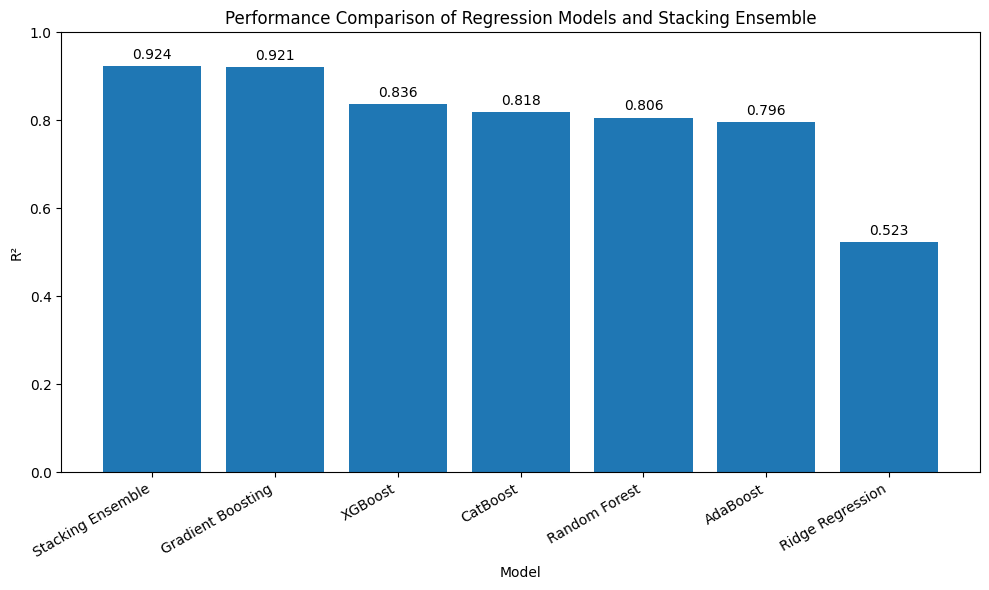

In [135]:
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------------------
# FIGURE 9: R² comparison of individual models + stacking
# ---------------------------------------------------------

# Make a copy
plot_df = results_df.copy()

# Remove Linear Regression and Lasso if present
plot_df = plot_df[
    ~plot_df["Model"].str.lower().isin([
        "linear regression",
        "linear",
        "lasso",
        "lasso regression"
    ])
].copy()

# Keep only the models you want in the manuscript
desired_models = [
    "Gradient Boosting",
    "XGBoost",
    "CatBoost",
    "Random Forest",
    "AdaBoost",
    "Ridge Regression",
    "Stacking Ensemble"
]

plot_df = plot_df[
    plot_df["Model"].isin(desired_models)
].copy()

# Sort by R² from highest to lowest
plot_df = plot_df.sort_values(
    by="R²",
    ascending=False
)

# ---------------------------------------------------------
# Create bar plot
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

bars = plt.bar(
    plot_df["Model"],
    plot_df["R²"]
)

# Add R² values on top of bars
for bar, value in zip(bars, plot_df["R²"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.ylabel("R²")
plt.xlabel("Model")
plt.title("Performance Comparison of Regression Models and Stacking Ensemble")

plt.ylim(0, 1.0)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    "Figure_9_Model_Performance_R2.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

               Model        R²
0  Stacking Ensemble  0.923645
1  Gradient Boosting  0.920577
2            XGBoost  0.836444
3           CatBoost  0.818369
4      Random Forest  0.806262
5           AdaBoost  0.795962
6   Ridge Regression  0.522718


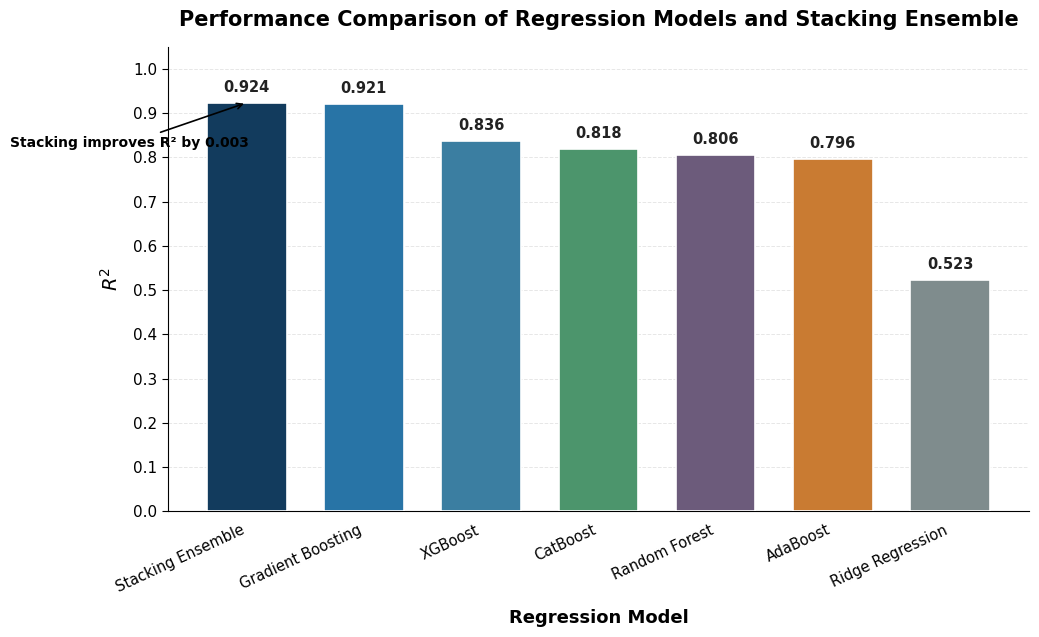

In [146]:
# =============================================================================
# Figure 9: R² Comparison of Individual Regression Models and Stacking Ensemble
# Publication-quality version
# =============================================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -----------------------------------------------------------------------------
# Make a copy
# -----------------------------------------------------------------------------

plot_df = results_df.copy()

# -----------------------------------------------------------------------------
# Remove Linear Regression and Lasso if present
# -----------------------------------------------------------------------------

plot_df = plot_df[
    ~plot_df["Model"].str.lower().isin([
        "linear regression",
        "linear",
        "lasso",
        "lasso regression"
    ])
].copy()

# -----------------------------------------------------------------------------
# Models included in the manuscript
# -----------------------------------------------------------------------------

desired_models = [
    "Gradient Boosting",
    "XGBoost",
    "CatBoost",
    "Random Forest",
    "AdaBoost",
    "Ridge Regression",
    "Stacking Ensemble"
]

plot_df = plot_df[
    plot_df["Model"].isin(desired_models)
].copy()

# -----------------------------------------------------------------------------
# Sort according to R²
# -----------------------------------------------------------------------------

plot_df = plot_df.sort_values(
    by="R²",
    ascending=False
).reset_index(drop=True)

print(plot_df[["Model", "R²"]])

# -----------------------------------------------------------------------------
# Publication-quality settings
# -----------------------------------------------------------------------------

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "xtick.labelsize": 10.5,
    "ytick.labelsize": 11,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

# -----------------------------------------------------------------------------
# Create figure
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10.5, 6.5))

# -----------------------------------------------------------------------------
# Colors
# -----------------------------------------------------------------------------

# Individual models
model_colors = {
    "Gradient Boosting": "#2874A6",
    "XGBoost": "#3B7EA1",
    "CatBoost": "#4C956C",
    "Random Forest": "#6C5B7B",
    "AdaBoost": "#C97B32",
    "Ridge Regression": "#7F8C8D",
    
    # Highlight the ensemble
    "Stacking Ensemble": "#123B5D"
}

colors = [
    model_colors[model]
    for model in plot_df["Model"]
]

# -----------------------------------------------------------------------------
# Bar plot
# -----------------------------------------------------------------------------

bars = ax.bar(
    plot_df["Model"],
    plot_df["R²"],
    color=colors,
    width=0.68,
    edgecolor="white",
    linewidth=1.2,
    zorder=3
)

# -----------------------------------------------------------------------------
# Add R² values
# -----------------------------------------------------------------------------

for bar, value in zip(
    bars,
    plot_df["R²"]
):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.018,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=10.5,
        fontweight="bold",
        color="#222222"
    )

# -----------------------------------------------------------------------------
# Highlight stacking ensemble
# -----------------------------------------------------------------------------

stacking_index = plot_df.index[
    plot_df["Model"] == "Stacking Ensemble"
][0]

stacking_r2 = plot_df.loc[
    stacking_index,
    "R²"
]

# -----------------------------------------------------------------------------
# Annotation showing improvement over Gradient Boosting
# -----------------------------------------------------------------------------

gb_r2 = plot_df.loc[
    plot_df["Model"] == "Gradient Boosting",
    "R²"
].iloc[0]

improvement = stacking_r2 - gb_r2

ax.annotate(
    f"Stacking improves R² by {improvement:.3f}",
    xy=(
        stacking_index,
        stacking_r2
    ),
    xytext=(
        stacking_index - 1.0,
        stacking_r2 - 0.10
    ),
    fontsize=10,
    fontweight="bold",
    ha="center",
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.2
    )
)

# -----------------------------------------------------------------------------
# Axis labels
# -----------------------------------------------------------------------------

ax.set_ylabel(
    r"$R^2$",
    fontsize=14,
    fontweight="bold",
    labelpad=8
)

ax.set_xlabel(
    "Regression Model",
    fontsize=13,
    fontweight="bold",
    labelpad=10
)

ax.set_title(
    "Performance Comparison of Regression Models and Stacking Ensemble",
    fontsize=15,
    fontweight="bold",
    pad=15
)

# -----------------------------------------------------------------------------
# Y-axis
# -----------------------------------------------------------------------------

ax.set_ylim(0, 1.05)

ax.set_yticks(
    np.arange(0, 1.01, 0.1)
)

# -----------------------------------------------------------------------------
# Grid
# -----------------------------------------------------------------------------

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.30,
    zorder=0
)

ax.grid(
    axis="x",
    visible=False
)

# -----------------------------------------------------------------------------
# X-axis formatting
# -----------------------------------------------------------------------------

plt.xticks(
    rotation=25,
    ha="right"
)

ax.tick_params(
    axis="x",
    length=0,
    pad=8
)

ax.tick_params(
    axis="y",
    width=0.8,
    length=4
)

# -----------------------------------------------------------------------------
# Remove unnecessary borders
# -----------------------------------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

# -----------------------------------------------------------------------------
# Layout
# -----------------------------------------------------------------------------

plt.tight_layout()

# -----------------------------------------------------------------------------
# Save high-resolution PNG
# -----------------------------------------------------------------------------

plt.savefig(
    "Figure_9_Model_Performance_R2.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

# -----------------------------------------------------------------------------
# Save vector PDF
# -----------------------------------------------------------------------------

plt.savefig(
    "Figure_9_Model_Performance_R2.pdf",
    format="pdf",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

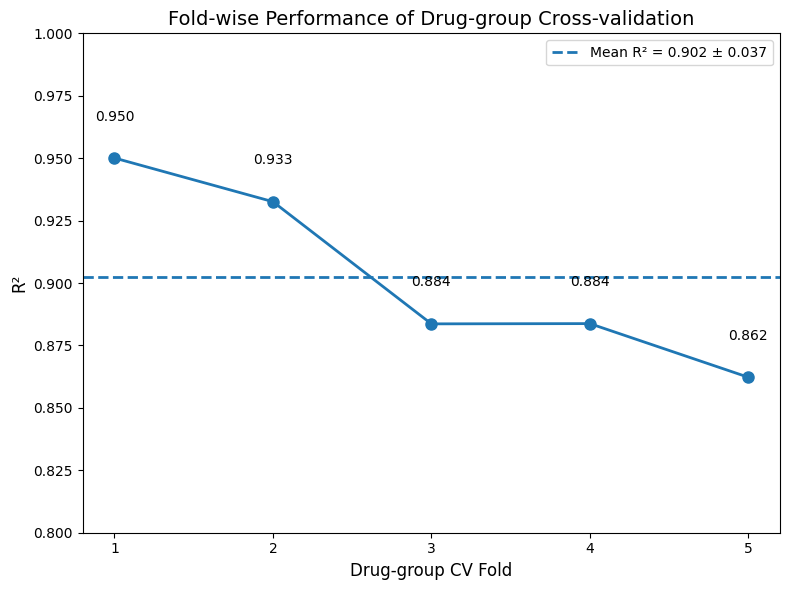

Mean R² : 0.902459
SD R²   : 0.037058


In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# FIGURE 11: Fold-wise performance of drug-group cross-validation
# ============================================================

# Your actual 5-fold R² results
results = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "R²": [
        0.950066,
        0.932574,
        0.883646,
        0.883748,
        0.862262
    ]
})

# Calculate mean and standard deviation
mean_r2 = results["R²"].mean()
std_r2 = results["R²"].std()

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    results["Fold"],
    results["R²"],
    marker="o",
    linewidth=2,
    markersize=8
)

# Mean line
plt.axhline(
    mean_r2,
    linestyle="--",
    linewidth=2,
    label=f"Mean R² = {mean_r2:.3f} ± {std_r2:.3f}"
)

# Add values above each point
for fold, r2 in zip(results["Fold"], results["R²"]):
    plt.text(
        fold,
        r2 + 0.015,
        f"{r2:.3f}",
        ha="center",
        fontsize=10
    )

plt.xlabel("Drug-group CV Fold", fontsize=12)
plt.ylabel("R²", fontsize=12)

plt.title(
    "Fold-wise Performance of Drug-group Cross-validation",
    fontsize=14
)

plt.xticks([1, 2, 3, 4, 5])
plt.ylim(0.80, 1.00)

plt.legend()

plt.tight_layout()

plt.savefig(
    "Figure_11_Drug_Group_CV_R2.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("Mean R² :", round(mean_r2, 6))
print("SD R²   :", round(std_r2, 6))

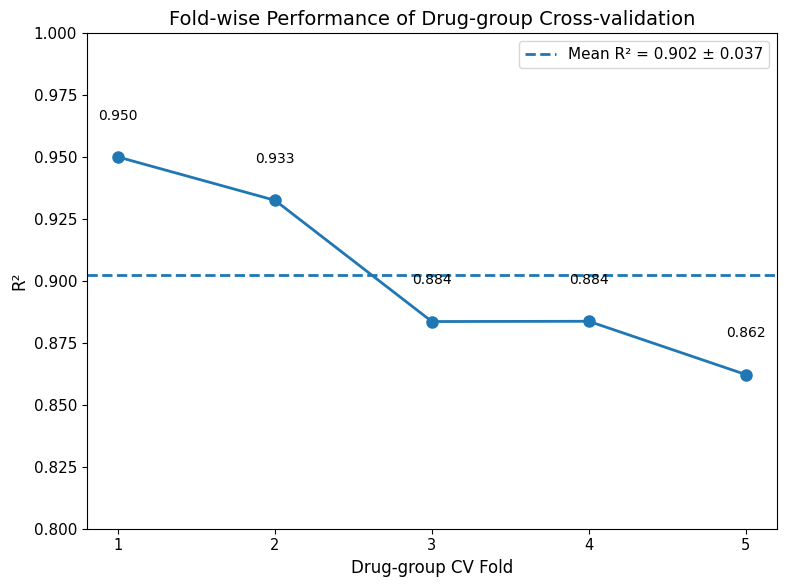

Mean R² : 0.902459
SD R²   : 0.037058


In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# FIGURE 11: Fold-wise performance of drug-group cross-validation
# ============================================================

# Your actual 5-fold R² results
results = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "R²": [
        0.950066,
        0.932574,
        0.883646,
        0.883748,
        0.862262
    ]
})

# Calculate mean and standard deviation
mean_r2 = results["R²"].mean()
std_r2 = results["R²"].std()

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    results["Fold"],
    results["R²"],
    marker="o",
    linewidth=2,
    markersize=8
)

# Mean line
plt.axhline(
    mean_r2,
    linestyle="--",
    linewidth=2,
    label=f"Mean R² = {mean_r2:.3f} ± {std_r2:.3f}"
)

# Add values above each point
for fold, r2 in zip(results["Fold"], results["R²"]):
    plt.text(
        fold,
        r2 + 0.015,
        f"{r2:.3f}",
        ha="center",
        fontsize=10
    )

plt.xlabel("Drug-group CV Fold", fontsize=12)
plt.ylabel("R²", fontsize=12)

plt.title(
    "Fold-wise Performance of Drug-group Cross-validation",
    fontsize=14
)

plt.xticks([1, 2, 3, 4, 5])
plt.ylim(0.80, 1.00)

plt.legend()

plt.tight_layout()

# ============================================================
# Save as PDF
# ============================================================

plt.savefig(
    "Figure_11_Drug_Group_CV_R2.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

print("Mean R² :", round(mean_r2, 6))
print("SD R²   :", round(std_r2, 6))

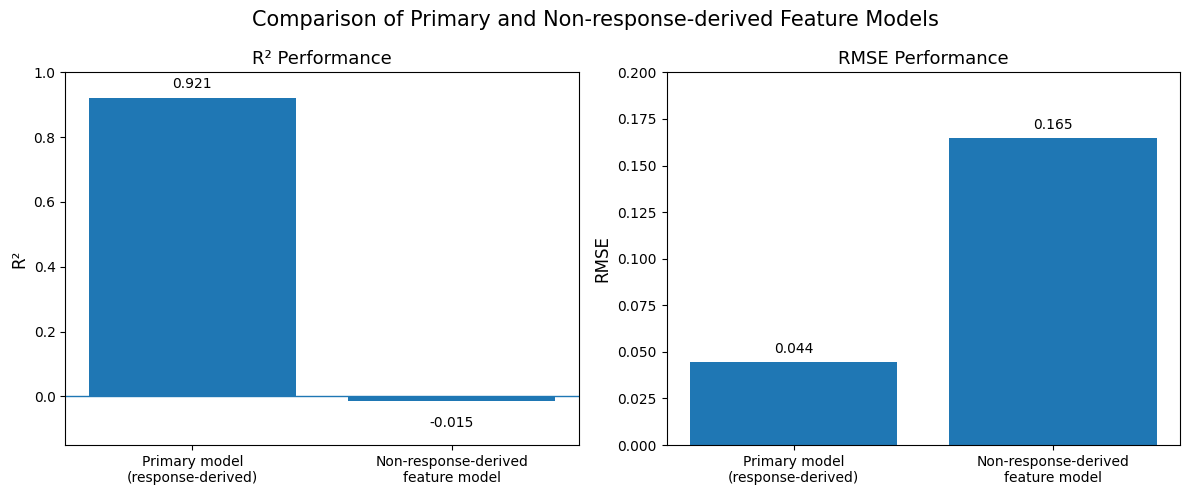

In [138]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# FIGURE 12
# Primary vs Non-response-derived Feature Model
# ============================================================

models = [
    "Primary model\n(response-derived)",
    "Non-response-derived\nfeature model"
]

# Your actual results
r2_values = [
    0.920577,
    -0.014548921390727942
]

rmse_values = [
    0.044381,
    0.16462596499055857
]

# ============================================================
# Create figure with two panels
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5)
)

# ------------------------------------------------------------
# R²
# ------------------------------------------------------------

bars1 = axes[0].bar(
    models,
    r2_values
)

axes[0].set_ylabel("R²", fontsize=12)
axes[0].set_title("R² Performance", fontsize=13)

# Important because one value is negative
axes[0].axhline(
    0,
    linewidth=1
)

# Add values
for bar, value in zip(bars1, r2_values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        value + (0.03 if value >= 0 else -0.08),
        f"{value:.3f}",
        ha="center",
        fontsize=10
    )

axes[0].set_ylim(-0.15, 1.0)

# ------------------------------------------------------------
# RMSE
# ------------------------------------------------------------

bars2 = axes[1].bar(
    models,
    rmse_values
)

axes[1].set_ylabel("RMSE", fontsize=12)
axes[1].set_title("RMSE Performance", fontsize=13)

# Add values
for bar, value in zip(bars2, rmse_values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.005,
        f"{value:.3f}",
        ha="center",
        fontsize=10
    )

axes[1].set_ylim(0, 0.20)

# ------------------------------------------------------------
# Overall formatting
# ------------------------------------------------------------

fig.suptitle(
    "Comparison of Primary and Non-response-derived Feature Models",
    fontsize=15
)

plt.tight_layout()

plt.savefig(
    "Figure_12_Primary_vs_NonResponse_Model.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

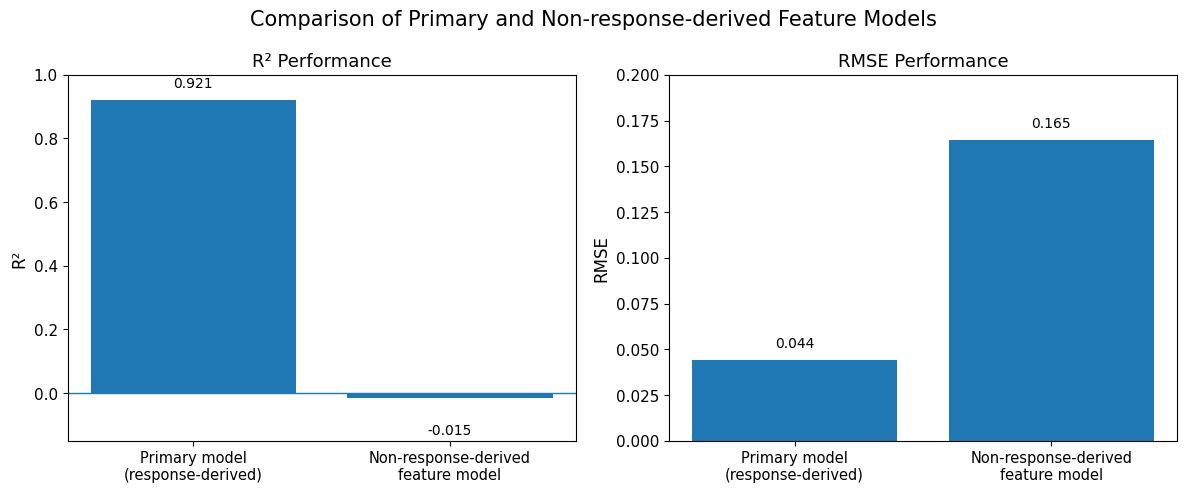

Primary model:
R²   = 0.920577
RMSE = 0.044381

Non-response-derived feature model:
R²   = -0.014549
RMSE = 0.164626

Figure saved as:
Figure_12_Primary_vs_NonResponse_Model.pdf


In [159]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# FIGURE 12
# Primary vs Non-response-derived Feature Model
# ============================================================

models = [
    "Primary model\n(response-derived)",
    "Non-response-derived\nfeature model"
]

# Your actual results
r2_values = [
    0.920577,
    -0.014548921390727942
]

rmse_values = [
    0.044381,
    0.16462596499055857
]

# ============================================================
# Create figure with two panels
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5)
)

# ============================================================
# R² Performance
# ============================================================

bars1 = axes[0].bar(
    models,
    r2_values
)

axes[0].set_ylabel("R²", fontsize=12)
axes[0].set_title("R² Performance", fontsize=13)

# Zero reference line
axes[0].axhline(
    0,
    linewidth=1
)

# Add R² values
for bar, value in zip(bars1, r2_values):

    if value >= 0:
        y_position = value + 0.03
        vertical_alignment = "bottom"
    else:
        y_position = value - 0.08
        vertical_alignment = "top"

    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        y_position,
        f"{value:.3f}",
        ha="center",
        va=vertical_alignment,
        fontsize=10
    )

axes[0].set_ylim(-0.15, 1.0)

# ============================================================
# RMSE Performance
# ============================================================

bars2 = axes[1].bar(
    models,
    rmse_values
)

axes[1].set_ylabel("RMSE", fontsize=12)
axes[1].set_title("RMSE Performance", fontsize=13)

# Add RMSE values
for bar, value in zip(bars2, rmse_values):

    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.005,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

axes[1].set_ylim(0, 0.20)

# ============================================================
# Overall formatting
# ============================================================

fig.suptitle(
    "Comparison of Primary and Non-response-derived Feature Models",
    fontsize=15
)

plt.tight_layout()

# ============================================================
# Save as publication-quality PDF
# ============================================================

plt.savefig(
    "Figure_12_Primary_vs_NonResponse_Model.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

# ============================================================
# Print results
# ============================================================

print("Primary model:")
print(f"R²   = {r2_values[0]:.6f}")
print(f"RMSE = {rmse_values[0]:.6f}")

print("\nNon-response-derived feature model:")
print(f"R²   = {r2_values[1]:.6f}")
print(f"RMSE = {rmse_values[1]:.6f}")

print("\nFigure saved as:")
print("Figure_12_Primary_vs_NonResponse_Model.pdf")


Prediction dataframe:
   Drug ID  Observed AUC  Predicted AUC
0     1021      0.810816       0.815926
1     1024      0.700826       0.611031
2     1009      0.967517       0.975477
3     1051      0.866051       0.836424
4     1814      0.983118       0.973856
5     1828      0.962021       0.953713
6     1585      0.974946       0.972631
7     2055      0.819506       0.814323
8     1083      0.914704       0.898473
9     1621      0.976432       0.972936

TABLE 6: TOP 10 COMPUTATIONALLY PRIORITIZED DRUG CANDIDATES
 Rank  Drug ID  Observed_Mean_AUC  Predicted_Mean_AUC  Number_of_Observations
    1     1034           0.069569            0.280783                       1
    2     1709           0.393863            0.494372                       1
    3     1708           0.525517            0.534611                       1
    4     1808           0.714462            0.557329                       1
    5     1024           0.700826            0.611031                       1
    6   

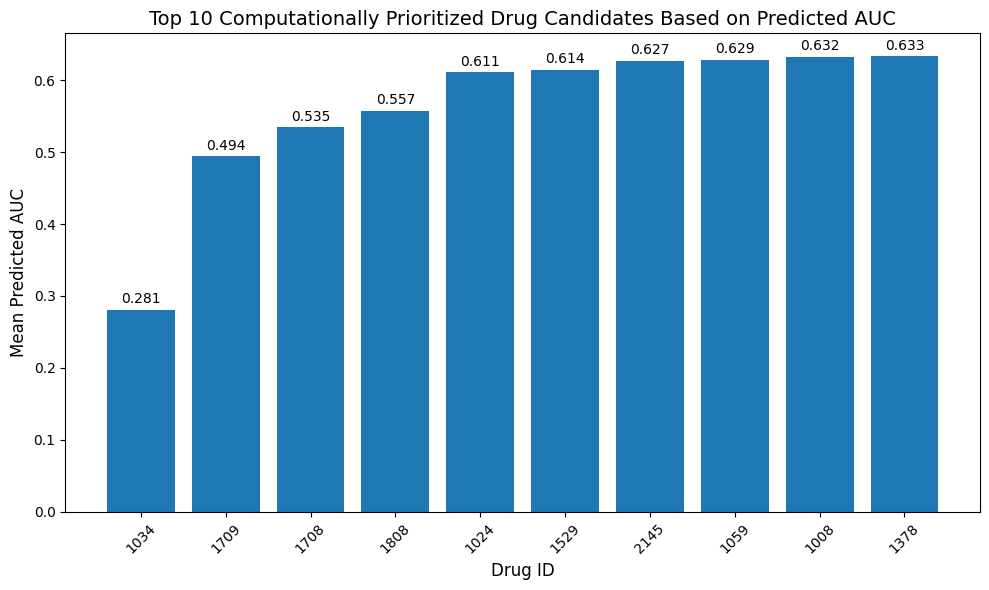

In [141]:
# =============================================================================
# TOP 10 COMPUTATIONALLY PRIORITIZED DRUG CANDIDATES
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt

# =============================================================================
# 1. Optimized Gradient Boosting model
# =============================================================================

best_gb = gb_grid.best_estimator_

# =============================================================================
# 2. Predict AUC on unseen test set
# =============================================================================

y_pred_gb = best_gb.predict(X_test)

# =============================================================================
# 3. Retrieve Drug IDs from original GBM dataset
# =============================================================================

test_drug_ids = gbm_data.loc[X_test.index, 'drug id'].values

# =============================================================================
# 4. Create prediction dataframe
# =============================================================================

prediction_df = pd.DataFrame({
    'Drug ID': test_drug_ids,
    'Observed AUC': y_test.values,
    'Predicted AUC': y_pred_gb
})

print("\nPrediction dataframe:")
print(prediction_df.head(10))

# =============================================================================
# 5. Aggregate predictions by Drug ID
# =============================================================================

drug_ranking = (
    prediction_df
    .groupby('Drug ID')
    .agg(
        Observed_Mean_AUC=('Observed AUC', 'mean'),
        Predicted_Mean_AUC=('Predicted AUC', 'mean'),
        Number_of_Observations=('Predicted AUC', 'count')
    )
    .reset_index()
)

# =============================================================================
# 6. Rank according to predicted AUC
# =============================================================================

# Lower predicted AUC = greater sensitivity
drug_ranking = drug_ranking.sort_values(
    by='Predicted_Mean_AUC',
    ascending=True
).reset_index(drop=True)

drug_ranking['Rank'] = range(
    1,
    len(drug_ranking) + 1
)

# =============================================================================
# 7. Select Top 10
# =============================================================================

top10_drugs = drug_ranking.head(10).copy()

top10_drugs = top10_drugs[
    [
        'Rank',
        'Drug ID',
        'Observed_Mean_AUC',
        'Predicted_Mean_AUC',
        'Number_of_Observations'
    ]
]

# =============================================================================
# 8. Display Table 6
# =============================================================================

print("\n" + "=" * 80)
print("TABLE 6: TOP 10 COMPUTATIONALLY PRIORITIZED DRUG CANDIDATES")
print("=" * 80)

print(
    top10_drugs.to_string(index=False)
)

# =============================================================================
# 9. Save Table 6
# =============================================================================

top10_drugs.to_csv(
    'Table_6_Top10_Prioritized_Drugs.csv',
    index=False
)

# =============================================================================
# 10. FIGURE 13
# =============================================================================

plt.figure(figsize=(10, 6))

bars = plt.bar(
    top10_drugs['Drug ID'].astype(str),
    top10_drugs['Predicted_Mean_AUC']
)

# Add values
for bar, value in zip(
    bars,
    top10_drugs['Predicted_Mean_AUC']
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{value:.3f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.xlabel('Drug ID', fontsize=12)
plt.ylabel('Mean Predicted AUC', fontsize=12)

plt.title(
    'Top 10 Computationally Prioritized Drug Candidates Based on Predicted AUC',
    fontsize=14
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    'Figure_13_Top10_Prioritized_Drugs.png',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

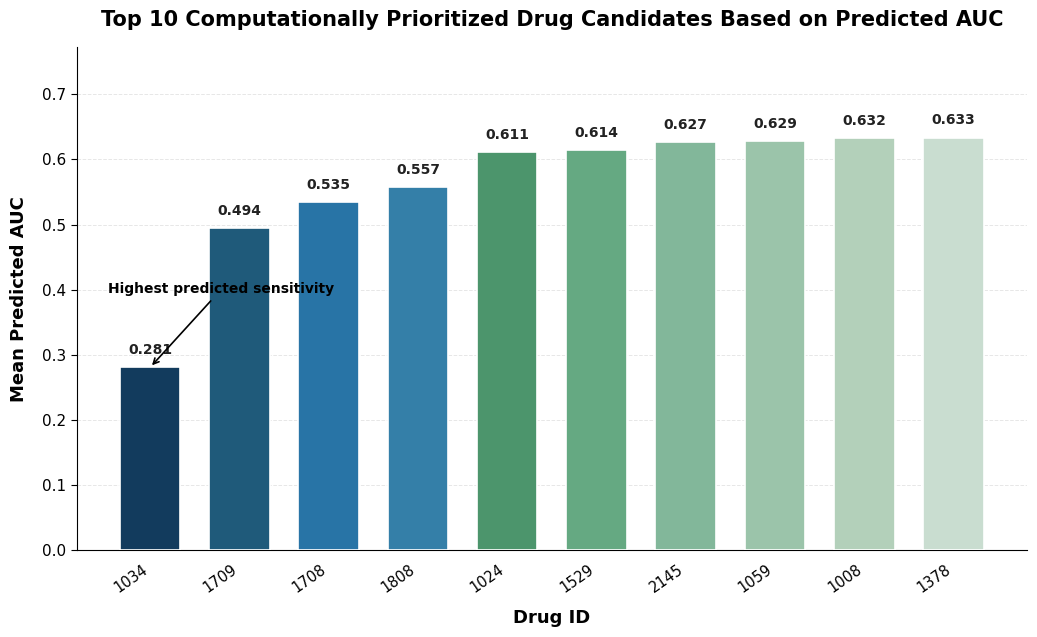

Figure 13 saved successfully:
  - Figure_13_Top10_Prioritized_Drugs.png
  - Figure_13_Top10_Prioritized_Drugs.pdf


In [150]:
# =============================================================================
# Figure 13: Top 10 Computationally Prioritized Drug Candidates Based on
#             Predicted AUC
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------------------------------------------------
# IMPORTANT:
# This code assumes `top10_drugs` already exists from your previous code.
# -----------------------------------------------------------------------------

# Sort by predicted AUC: lower AUC = greater predicted sensitivity
plot_df = top10_drugs.sort_values(
    by="Predicted_Mean_AUC",
    ascending=True
).reset_index(drop=True)

# -----------------------------------------------------------------------------
# Publication-quality settings
# -----------------------------------------------------------------------------

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "xtick.labelsize": 10.5,
    "ytick.labelsize": 11,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

# -----------------------------------------------------------------------------
# Create figure
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10.5, 6.5))

# -----------------------------------------------------------------------------
# Professional color palette
# Darker color = strongest predicted sensitivity
# -----------------------------------------------------------------------------

colors = [
    "#123B5D",
    "#1F5A7A",
    "#2874A6",
    "#347FA8",
    "#4C956C",
    "#65A982",
    "#82B79A",
    "#9BC4AA",
    "#B3D0BA",
    "#C9DDD0"
]

# -----------------------------------------------------------------------------
# Bar plot
# -----------------------------------------------------------------------------

bars = ax.bar(
    plot_df["Drug ID"].astype(str),
    plot_df["Predicted_Mean_AUC"],
    color=colors,
    width=0.68,
    edgecolor="white",
    linewidth=1.2,
    zorder=3
)

# -----------------------------------------------------------------------------
# Add predicted AUC values
# -----------------------------------------------------------------------------

max_auc = plot_df["Predicted_Mean_AUC"].max()

for bar, value in zip(
    bars,
    plot_df["Predicted_Mean_AUC"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + max_auc * 0.025,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#222222"
    )

# -----------------------------------------------------------------------------
# Highlight the highest-priority candidate
# -----------------------------------------------------------------------------

best_bar = bars[0]

ax.annotate(
    "Highest predicted sensitivity",
    xy=(
        best_bar.get_x() + best_bar.get_width() / 2,
        best_bar.get_height()
    ),
    xytext=(
        best_bar.get_x() + best_bar.get_width() / 2 + 0.8,
        best_bar.get_height() + max_auc * 0.18
    ),
    fontsize=10,
    fontweight="bold",
    ha="center",
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.2
    )
)

# -----------------------------------------------------------------------------
# Labels
# -----------------------------------------------------------------------------

ax.set_xlabel(
    "Drug ID",
    fontsize=13,
    fontweight="bold",
    labelpad=10
)

ax.set_ylabel(
    "Mean Predicted AUC",
    fontsize=13,
    fontweight="bold",
    labelpad=10
)

ax.set_title(
    "Top 10 Computationally Prioritized Drug Candidates Based on Predicted AUC",
    fontsize=15,
    fontweight="bold",
    pad=15
)

# -----------------------------------------------------------------------------
# Grid
# -----------------------------------------------------------------------------

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.30,
    zorder=0
)

ax.grid(
    axis="x",
    visible=False
)

# -----------------------------------------------------------------------------
# X-axis formatting
# -----------------------------------------------------------------------------

plt.xticks(
    rotation=35,
    ha="right"
)

ax.tick_params(
    axis="x",
    length=0,
    pad=8
)

ax.tick_params(
    axis="y",
    width=0.8,
    length=4
)

# -----------------------------------------------------------------------------
# Remove unnecessary borders
# -----------------------------------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

# -----------------------------------------------------------------------------
# Y-axis limit
# -----------------------------------------------------------------------------

ax.set_ylim(
    0,
    max_auc * 1.22
)

# -----------------------------------------------------------------------------
# Layout
# -----------------------------------------------------------------------------

plt.tight_layout()

# -----------------------------------------------------------------------------
# Save high-resolution PNG
# -----------------------------------------------------------------------------

plt.savefig(
    "Figure_13_Top10_Prioritized_Drugs.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

# -----------------------------------------------------------------------------
# Save vector PDF
# -----------------------------------------------------------------------------

plt.savefig(
    "Figure_13_Top10_Prioritized_Drugs.pdf",
    format="pdf",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Figure 13 saved successfully:")
print("  - Figure_13_Top10_Prioritized_Drugs.png")
print("  - Figure_13_Top10_Prioritized_Drugs.pdf")

NameError: name 'results_dir' is not defined

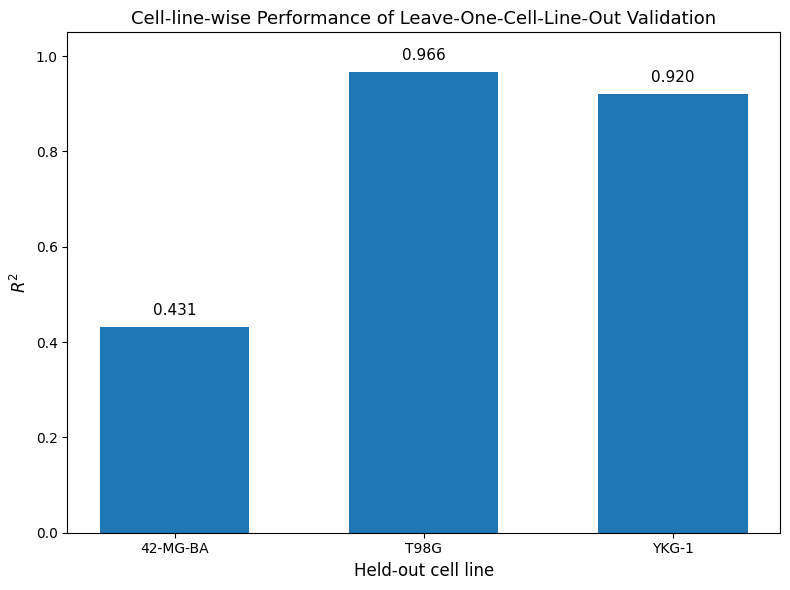

In [142]:
import matplotlib.pyplot as plt
import numpy as np
import os

# ============================================================
# FIGURE 10: Cell-line-wise performance of leave-one-cell-line-out
# ============================================================

# Results from Table 3
cell_lines = ['42-MG-BA', 'T98G', 'YKG-1']
r2_values = [0.430925, 0.966335, 0.920402]

# Create figure
plt.figure(figsize=(8, 6))

bars = plt.bar(
    cell_lines,
    r2_values,
    width=0.6
)

# Add R² values above bars
for bar, value in zip(bars, r2_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f'{value:.3f}',
        ha='center',
        va='bottom',
        fontsize=11
    )

# Labels and title
plt.xlabel('Held-out cell line', fontsize=12)
plt.ylabel(r'$R^2$', fontsize=12)
plt.title(
    'Cell-line-wise Performance of Leave-One-Cell-Line-Out Validation',
    fontsize=13
)

# Set y-axis
plt.ylim(0, 1.05)

# Improve layout
plt.tight_layout()

# Save figure
plt.savefig(
    os.path.join(results_dir, 'Figure_10_Cell_Line_LOCO_R2.png'),
    dpi=600,
    bbox_inches='tight'
)

plt.show()

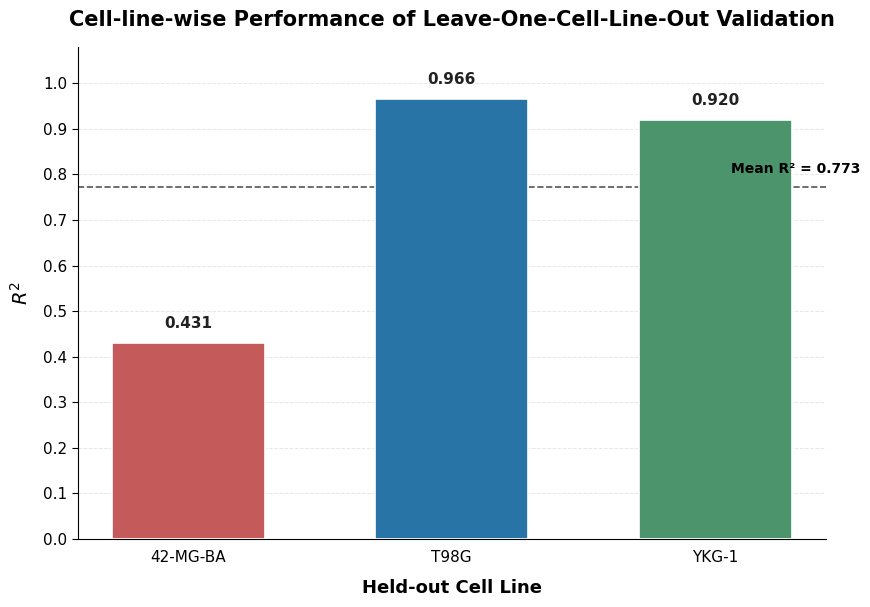

Figure 10 saved successfully:
  - Figure_10_Cell_Line_LOCO_R2.png
  - Figure_10_Cell_Line_LOCO_R2.pdf


In [149]:
# =============================================================================
# Figure 10: Cell-line-wise Performance of Leave-One-Cell-Line-Out Validation
# Publication-quality version
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------------------------------------------------
# Results from Table 3
# -----------------------------------------------------------------------------

cell_lines = [
    "42-MG-BA",
    "T98G",
    "YKG-1"
]

r2_values = [
    0.430925,
    0.966335,
    0.920402
]

# -----------------------------------------------------------------------------
# Publication-quality settings
# -----------------------------------------------------------------------------

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

# -----------------------------------------------------------------------------
# Create figure
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8.8, 6.2))

# -----------------------------------------------------------------------------
# Professional color palette
# -----------------------------------------------------------------------------

colors = [
    "#C55A5A",   # 42-MG-BA
    "#2874A6",   # T98G
    "#4C956C"    # YKG-1
]

# -----------------------------------------------------------------------------
# Bar plot
# -----------------------------------------------------------------------------

bars = ax.bar(
    cell_lines,
    r2_values,
    width=0.58,
    color=colors,
    edgecolor="white",
    linewidth=1.2,
    zorder=3
)

# -----------------------------------------------------------------------------
# Add R² values above bars
# -----------------------------------------------------------------------------

for bar, value in zip(bars, r2_values):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.025,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color="#222222"
    )

# -----------------------------------------------------------------------------
# Mean R² across held-out cell lines
# -----------------------------------------------------------------------------

mean_r2 = np.mean(r2_values)

ax.axhline(
    mean_r2,
    linestyle="--",
    linewidth=1.2,
    color="#555555",
    zorder=2
)

ax.text(
    len(cell_lines) - 0.45,
    mean_r2 + 0.025,
    f"Mean R² = {mean_r2:.3f}",
    fontsize=10,
    fontweight="bold",
    ha="right",
    va="bottom"
)

# -----------------------------------------------------------------------------
# Labels
# -----------------------------------------------------------------------------

ax.set_xlabel(
    "Held-out Cell Line",
    fontsize=13,
    fontweight="bold",
    labelpad=10
)

ax.set_ylabel(
    r"$R^2$",
    fontsize=14,
    fontweight="bold",
    labelpad=8
)

ax.set_title(
    "Cell-line-wise Performance of Leave-One-Cell-Line-Out Validation",
    fontsize=15,
    fontweight="bold",
    pad=15
)

# -----------------------------------------------------------------------------
# Y-axis
# -----------------------------------------------------------------------------

ax.set_ylim(0, 1.08)

ax.set_yticks(
    np.arange(0, 1.01, 0.1)
)

# -----------------------------------------------------------------------------
# Grid
# -----------------------------------------------------------------------------

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.30,
    zorder=0
)

ax.grid(
    axis="x",
    visible=False
)

# -----------------------------------------------------------------------------
# Tick formatting
# -----------------------------------------------------------------------------

ax.tick_params(
    axis="x",
    length=0,
    pad=8
)

ax.tick_params(
    axis="y",
    width=0.8,
    length=4
)

# -----------------------------------------------------------------------------
# Remove unnecessary borders
# -----------------------------------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

# -----------------------------------------------------------------------------
# Layout
# -----------------------------------------------------------------------------

plt.tight_layout()

# -----------------------------------------------------------------------------
# Save high-resolution PNG
# Saves directly in the current working folder
# -----------------------------------------------------------------------------

plt.savefig(
    "Figure_10_Cell_Line_LOCO_R2.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

# -----------------------------------------------------------------------------
# Save vector PDF
# Saves directly in the current working folder
# -----------------------------------------------------------------------------

plt.savefig(
    "Figure_10_Cell_Line_LOCO_R2.pdf",
    format="pdf",
    bbox_inches="tight",
    facecolor="white"
)

# -----------------------------------------------------------------------------
# Display figure
# -----------------------------------------------------------------------------

plt.show()

# -----------------------------------------------------------------------------
# Confirmation
# -----------------------------------------------------------------------------

print("Figure 10 saved successfully:")
print("  - Figure_10_Cell_Line_LOCO_R2.png")
print("  - Figure_10_Cell_Line_LOCO_R2.pdf")

In [148]:
# -----------------------------------------------------------------------------
# Save high-resolution PNG in the current working folder
# -----------------------------------------------------------------------------

plt.savefig(
    "Figure_10_Cell_Line_LOCO_R2.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

# -----------------------------------------------------------------------------
# Save vector PDF in the current working folder
# -----------------------------------------------------------------------------

plt.savefig(
    "Figure_10_Cell_Line_LOCO_R2.pdf",
    format="pdf",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

<Figure size 640x480 with 0 Axes>